data based on running 

`python Calibration.py ../../configs/unbinned/unbinned_2016.yaml --job bit_pod_TTLep_pow_2016 --write_pandas`

with the `--write_pandas` added by me to write out csv file to disk.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [2]:
data = pd.read_csv("delphes/calib_prediction_valid.csv", index_col=0)

In [3]:
data.head(10)

,c0_truth,c0_pred,c1_truth,c1_pred,c2_truth,c2_pred,c3_truth,c3_pred,c4_truth,c4_pred,...,c3 * c4_pred,c3 * c5_truth,c3 * c5_pred,c4^2_truth,c4^2_pred,c4 * c5_truth,c4 * c5_pred,c5^2_truth,c5^2_pred,weight
0,-0.046061,-0.139712,-0.002937,0.067017,-0.058573,-0.006110,0.100813,0.093699,-0.102451,-0.156977,...,-0.010092,-0.001414,-0.005846,-0.000731,0.002310,0.000514,0.006131,0.000383,0.004917,0.000264
1,-0.407310,-0.173099,0.401839,0.088365,0.428626,0.002200,-0.259553,0.097953,-0.063446,-0.144559,...,-0.009984,-0.007780,-0.004469,0.000046,0.003520,0.002238,0.004262,0.017051,0.003029,0.000264
2,-0.582656,-0.344207,0.542733,0.248286,0.535769,0.150038,-0.304990,0.036057,0.012545,-0.158983,...,-0.009686,-0.031820,-0.009421,-0.005810,0.007879,0.010210,0.003666,-0.002629,0.000960,0.000264
3,-0.038916,-0.129687,-0.098840,0.036662,-0.251897,-0.062925,0.318077,0.158808,-0.268125,-0.204996,...,-0.015540,-0.012767,-0.008592,-0.010142,0.001660,0.010043,0.006844,0.003565,0.005275,0.000264
4,-0.020917,-0.124579,-0.027911,-0.020404,-0.080122,-0.174343,0.094561,0.245347,-0.052330,-0.143910,...,-0.016996,-0.000695,0.000364,0.001279,0.009729,0.000177,0.000137,-0.000094,-0.000099,0.000264
5,-0.355843,-0.287572,0.252378,0.236468,0.145054,0.200079,0.064261,-0.081680,-0.245835,-0.024767,...,0.004279,-0.021352,-0.000266,0.013158,-0.002528,0.008181,0.000951,0.004487,0.001737,0.000264
6,-0.339120,-0.408611,0.148022,0.272040,-0.077115,0.117814,0.320000,0.120919,-0.340907,-0.198601,...,-0.014812,-0.009642,-0.002092,0.044903,0.020480,0.003077,0.001819,-0.001776,-0.000347,0.000264
7,-0.384658,-0.115680,0.204707,-0.034550,-0.007999,-0.194543,0.278609,0.263060,-0.362755,-0.154372,...,-0.019593,-0.017414,-0.000114,0.047037,0.010584,0.006253,0.000321,-0.002920,0.000117,0.000264
8,-0.166743,-0.099656,-0.009787,-0.044996,-0.205367,-0.198152,0.321249,0.258074,-0.227085,-0.152733,...,-0.019086,-0.001640,-0.001091,0.013523,0.009244,0.000105,0.000888,-0.000071,0.000149,0.000264
9,-0.202926,-0.169786,0.012636,0.050697,-0.200494,-0.077098,0.335429,0.185935,-0.223147,-0.187795,...,-0.017490,0.002782,-0.005762,0.023931,0.006644,-0.001967,0.003842,0.000112,0.002043,0.000264


In [4]:
label = []
truth_list = []
pred_list = []

for elem in data:
    tmp_label = elem.split('_')[0]
    if tmp_label in label:
        pass
    else:
        label.append(tmp_label)
    if "_truth" in elem:
        truth_list.append(data[elem].to_numpy())
    elif "_pred" in elem:
        pred_list.append(data[elem].to_numpy())
    elif "weight" in elem:
        weights = data[elem].to_numpy()
    else:
        print("???")

truth_list = np.array(truth_list)
pred_list = np.array(pred_list)
        
print(len(label), label)
print(truth_list.shape)
print(pred_list.shape)
print(weights.shape)


28 ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c0^2', 'c0 * c1', 'c0 * c2', 'c0 * c3', 'c0 * c4', 'c0 * c5', 'c1^2', 'c1 * c2', 'c1 * c3', 'c1 * c4', 'c1 * c5', 'c2^2', 'c2 * c3', 'c2 * c4', 'c2 * c5', 'c3^2', 'c3 * c4', 'c3 * c5', 'c4^2', 'c4 * c5', 'c5^2', 'weight']
(27, 511466)
(27, 511466)
(511466,)


In [6]:
def weighted_mean(array, weight):
    return (array*weight).sum() / weight.sum() 
def weighted_std(array, weight):
    #var = weighted_mean(array**2, weight) - weighted_mean(array, weight)**2
    mean = weighted_mean(array, weight)
    var = weighted_mean((array-mean)**2, weight)
    return np.sqrt(np.abs(var))

def unweighted_std(array, weight=None):
    mean = np.mean(array)
    var = np.mean((array - mean)**2)
    return np.sqrt(var)

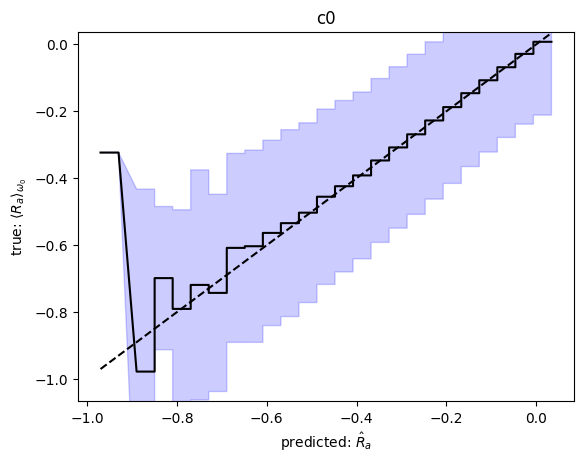

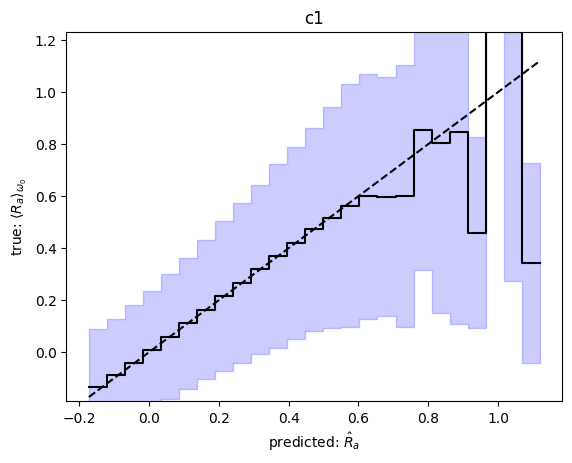

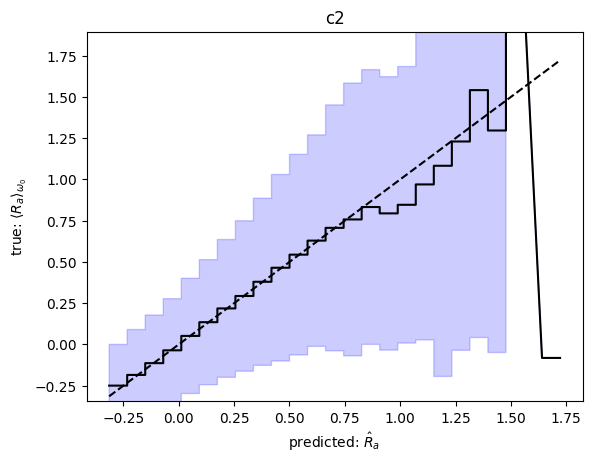

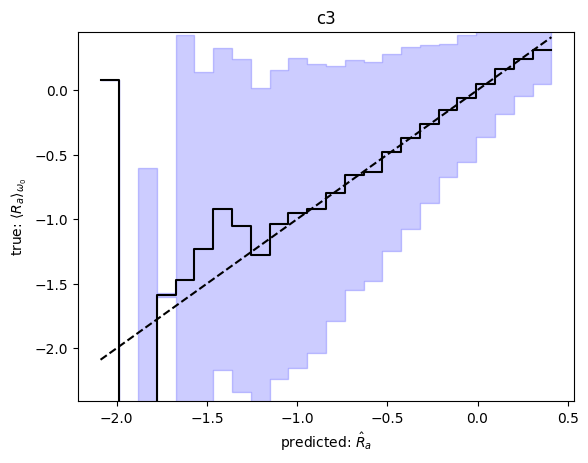

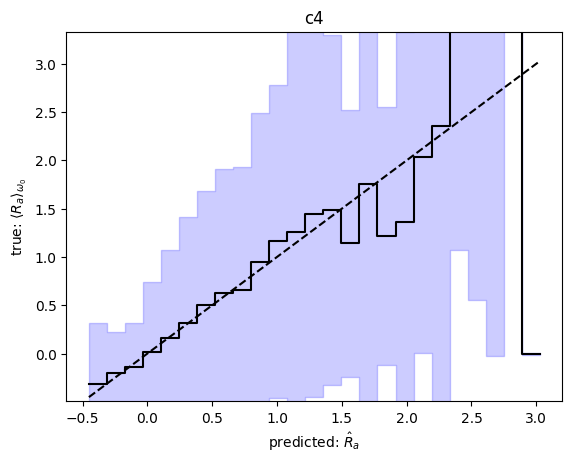

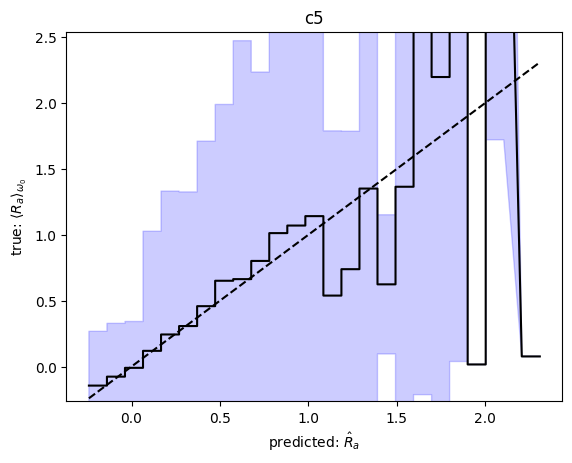

In [7]:
num_bins = 25

for idx, lab in enumerate(label):
    if lab not in ['c0', 'c1', 'c2', 'c3', 'c4', 'c5']:
        continue
    bins = np.linspace(pred_list[idx].min(),pred_list[idx].max(),num_bins+1)
    
    which_bin = (pred_list[idx] > bins[:-1].reshape(-1,1)) & (pred_list[idx] <= bins[1:].reshape(-1,1))
    tmp_truth = []
    tmp_pred = []
    tmp_std = []
    for i in range(num_bins):
        if len(pred_list[idx][which_bin[i]]) == 0:
            pass
        else:
            tmp_truth.append(weighted_mean(truth_list[idx][which_bin[i]], weights[which_bin[i]]))
            tmp_truth.append(weighted_mean(truth_list[idx][which_bin[i]], weights[which_bin[i]]))
            tmp_std.append(weighted_std(truth_list[idx][which_bin[i]], weights[which_bin[i]]))
            tmp_std.append(weighted_std(truth_list[idx][which_bin[i]], weights[which_bin[i]]))
            #tmp_pred.append(pred_list[idx][which_bin[i]].mean())
            tmp_pred.append(bins[i])
            tmp_pred.append(bins[i+1])
    tmp_truth = np.array(tmp_truth)
    tmp_pred = np.array(tmp_pred)
    tmp_std = np.array(tmp_std)
    plt.plot(tmp_pred, tmp_truth, color='k')
    plt.fill_between(tmp_pred, tmp_truth+tmp_std,tmp_truth-tmp_std , color='b',alpha=0.2)
    plt.plot([tmp_pred.min(),tmp_pred.max()], [tmp_pred.min(),tmp_pred.max()], 'k--', label='well calib.')
    plt.xlabel(r'predicted: $\hat{R}_a$')
    plt.ylabel(r'true: $\langle R_a \rangle_{\omega_0}$')
    plt.ylim(np.sign(bins[0])*1.1*np.abs(bins[0]), np.sign(bins[-1])*1.1*np.abs(bins[-1]))
    #if lab in ['c4']:
    #    plt.ylim(-2,2)
    #if lab in ['c5']:
    #    plt.ylim(-3,2)
    plt.title(label[idx])
    plt.show()

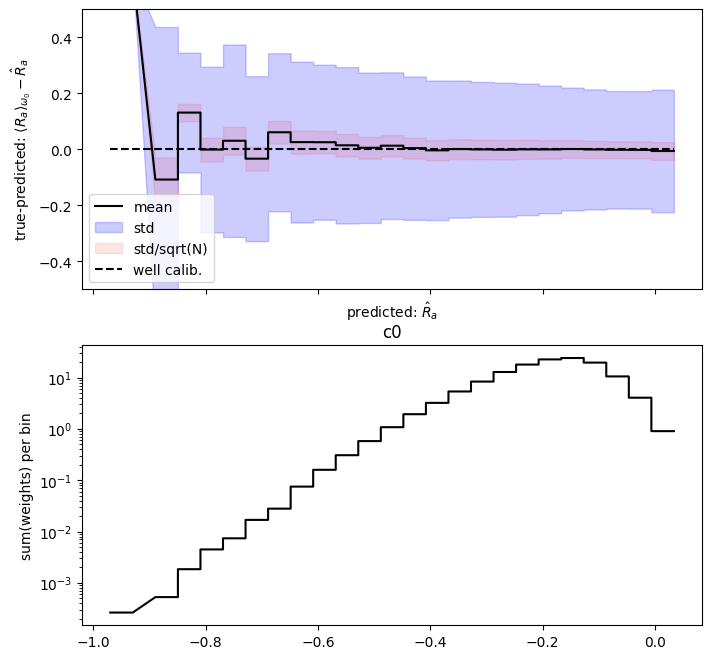

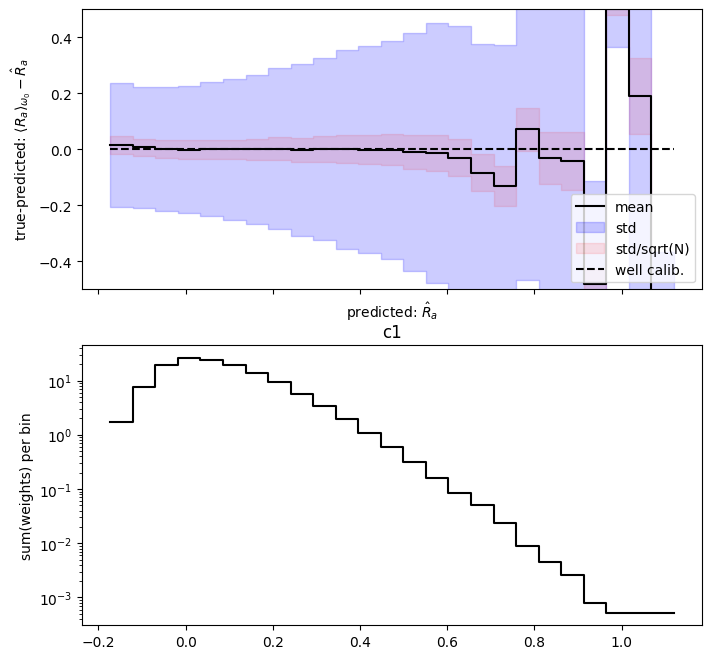

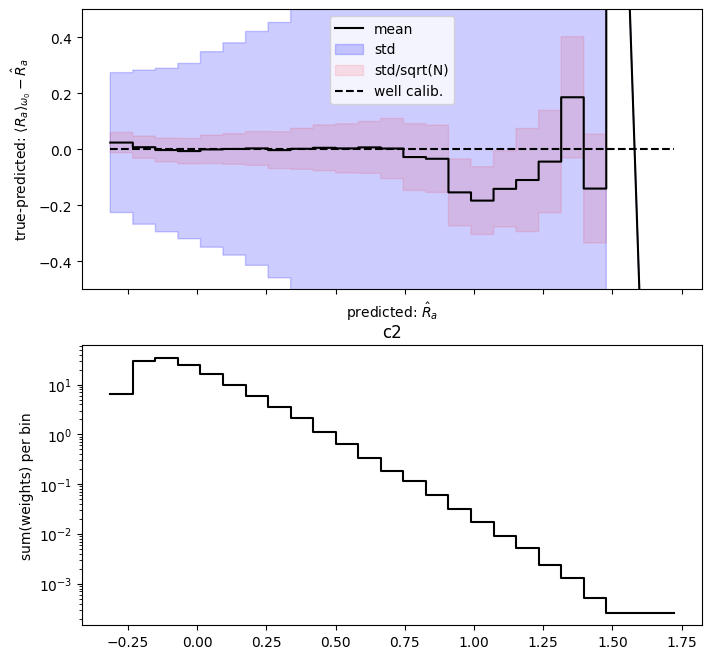

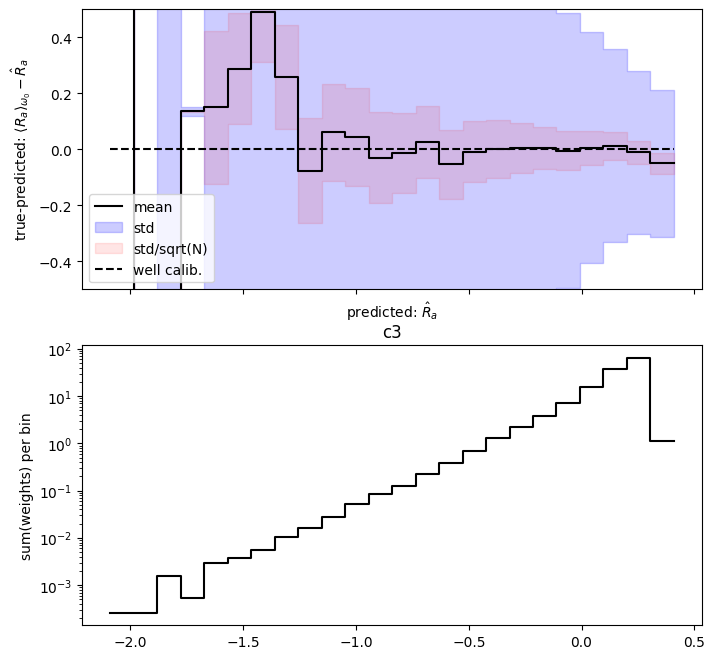

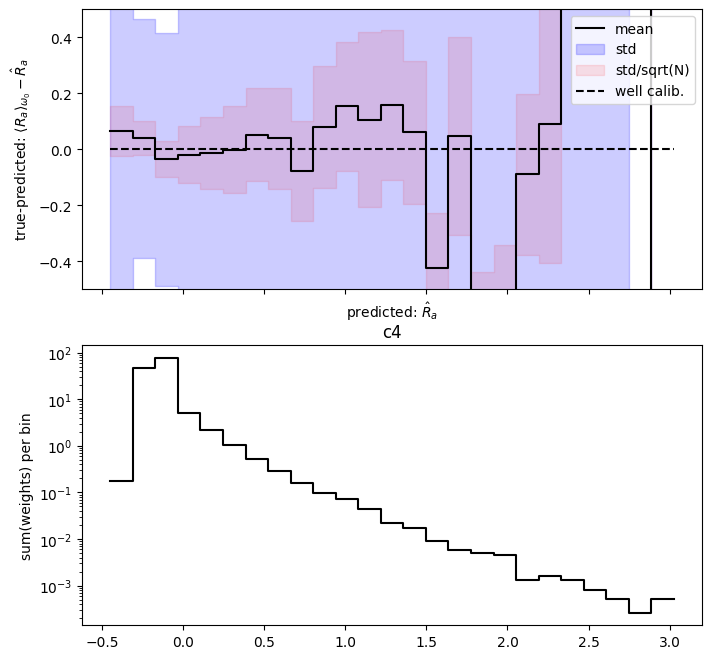

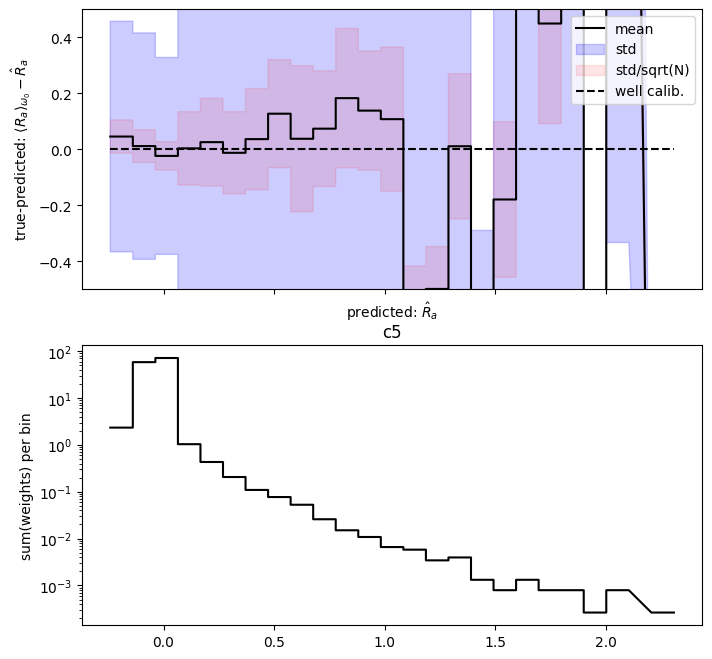

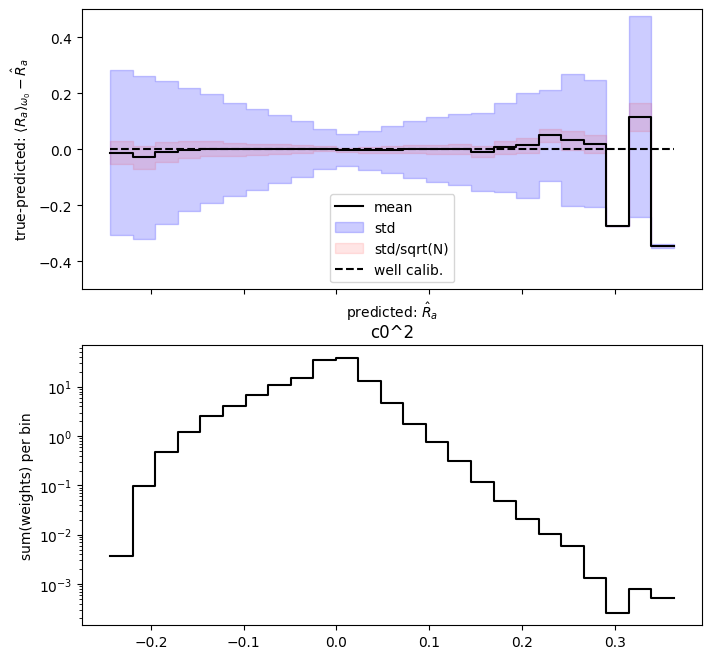

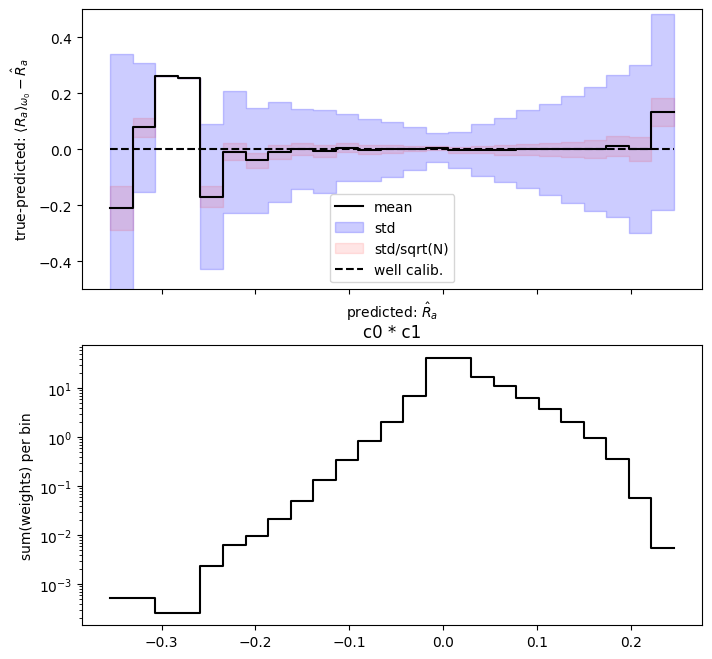

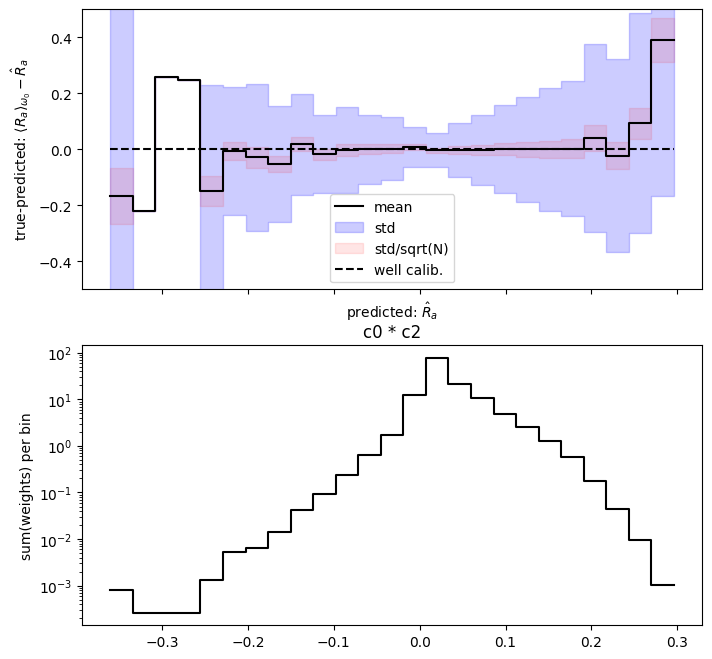

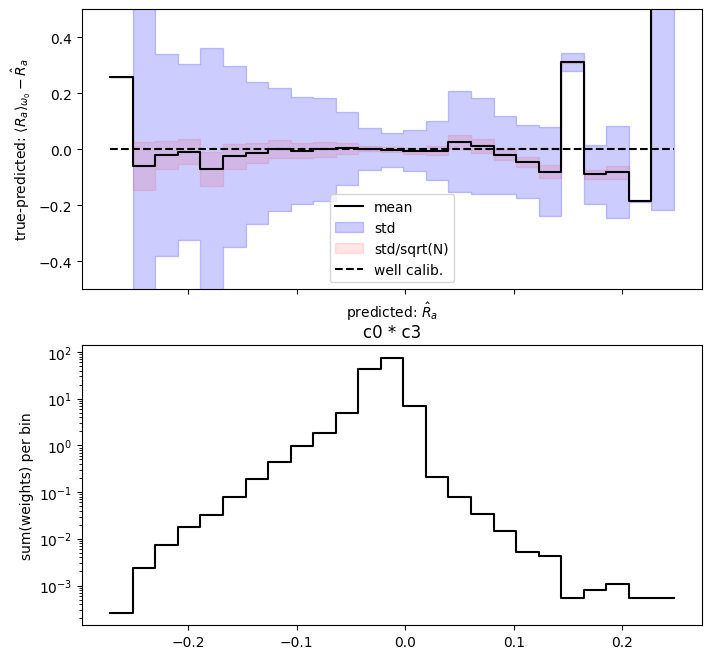

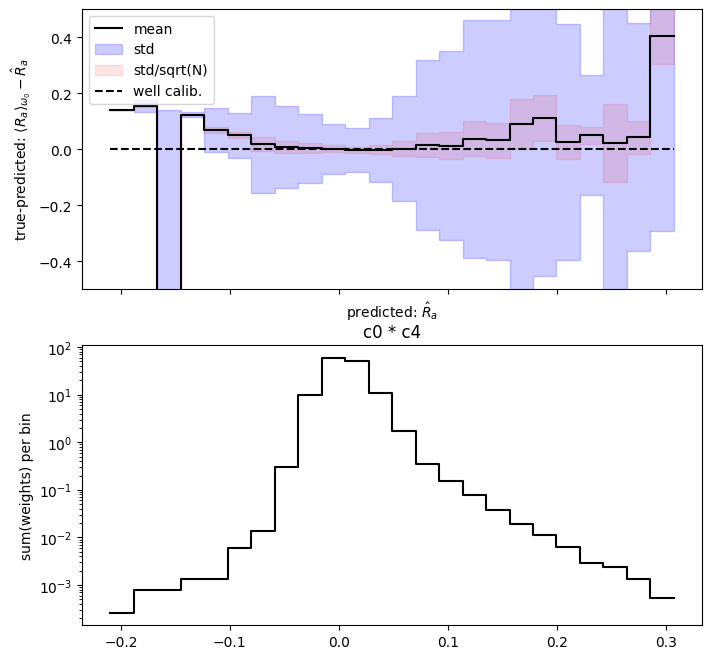

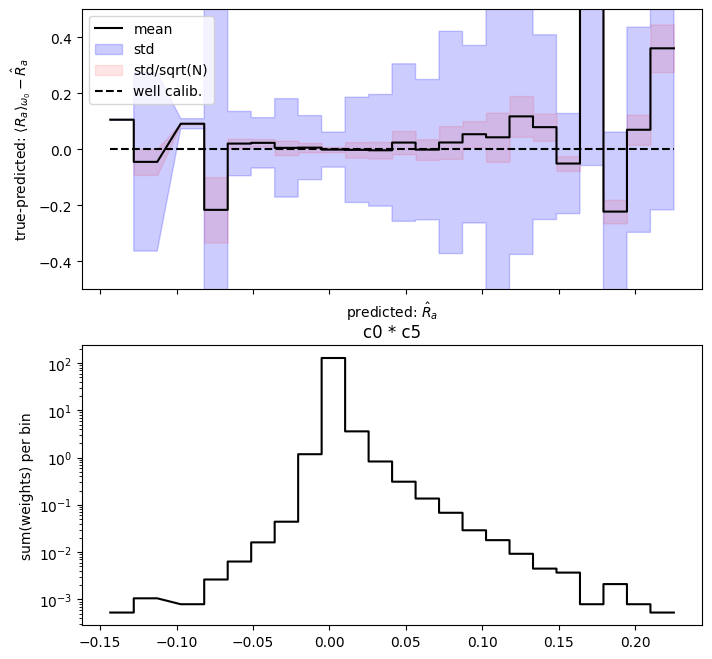

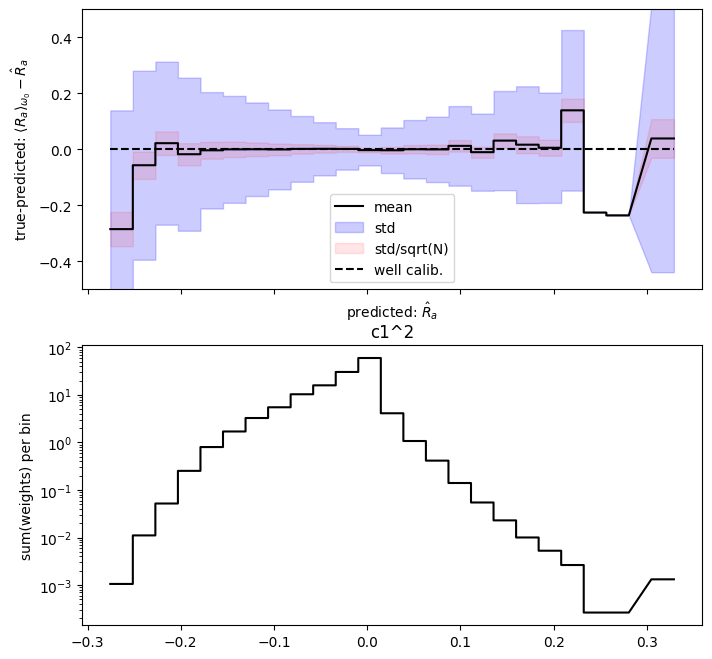

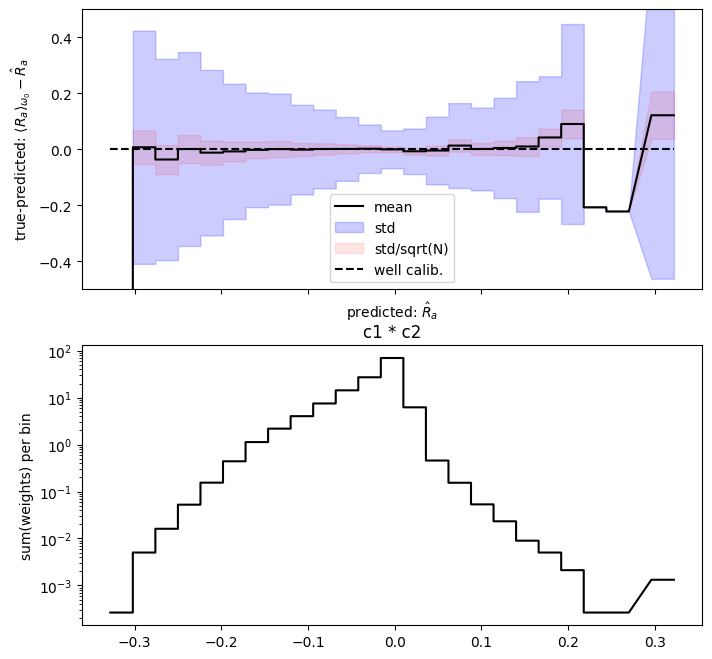

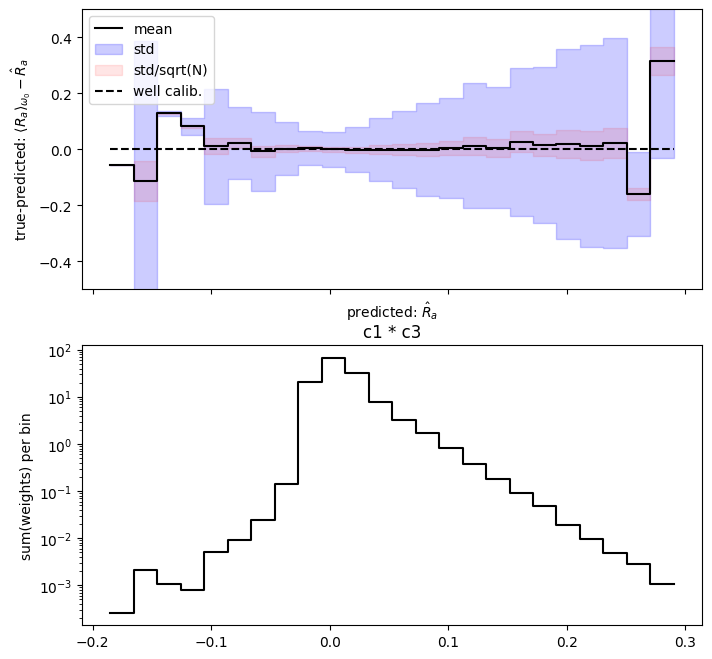

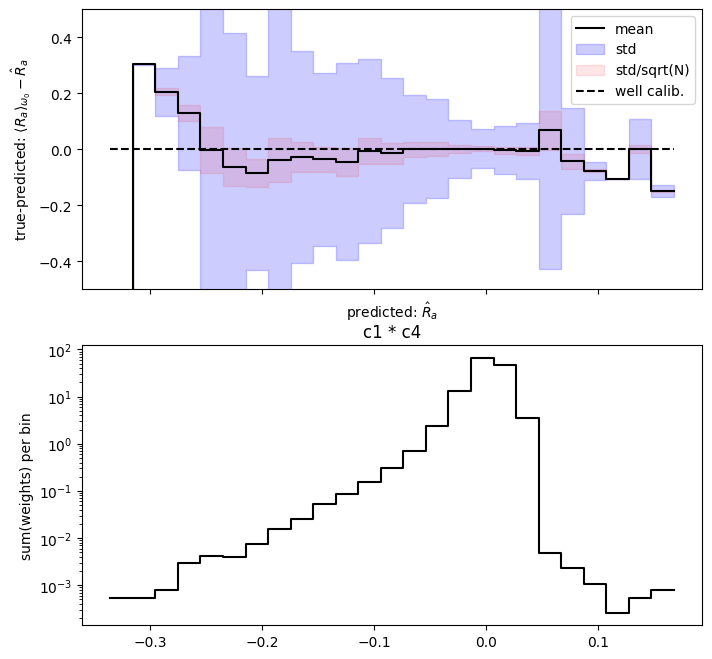

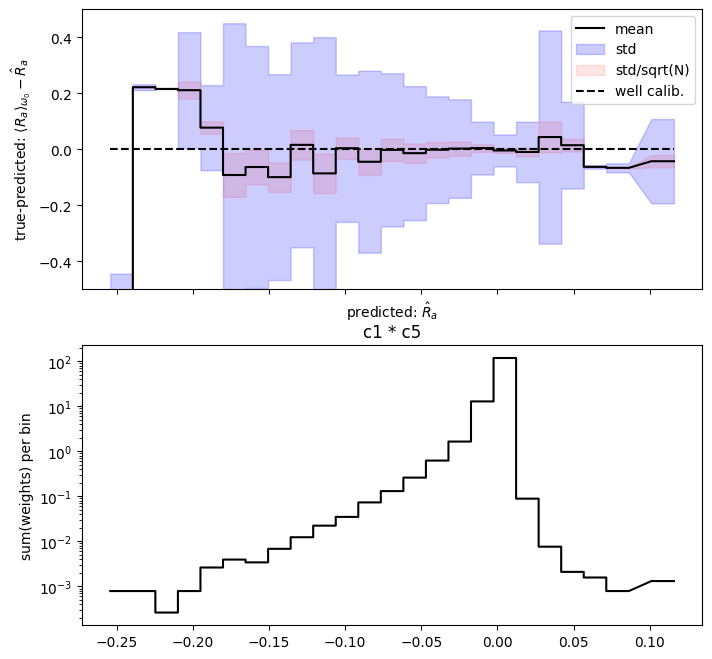

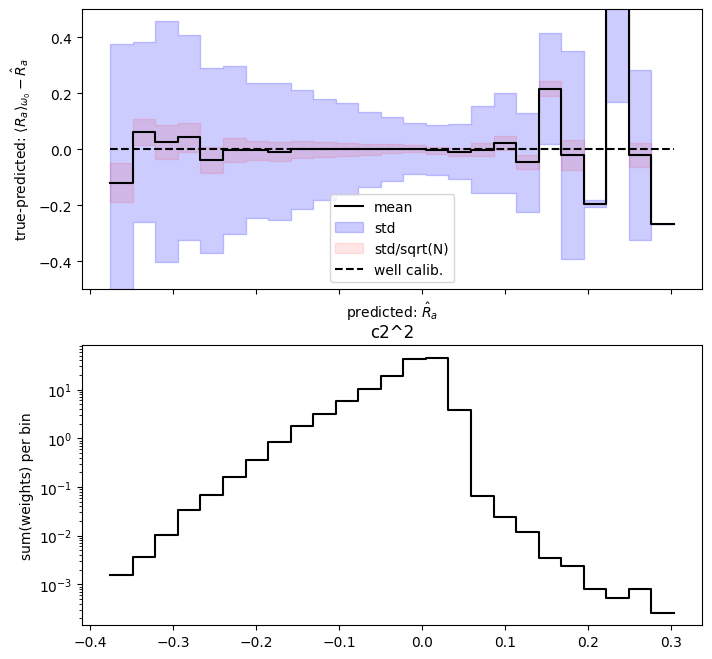

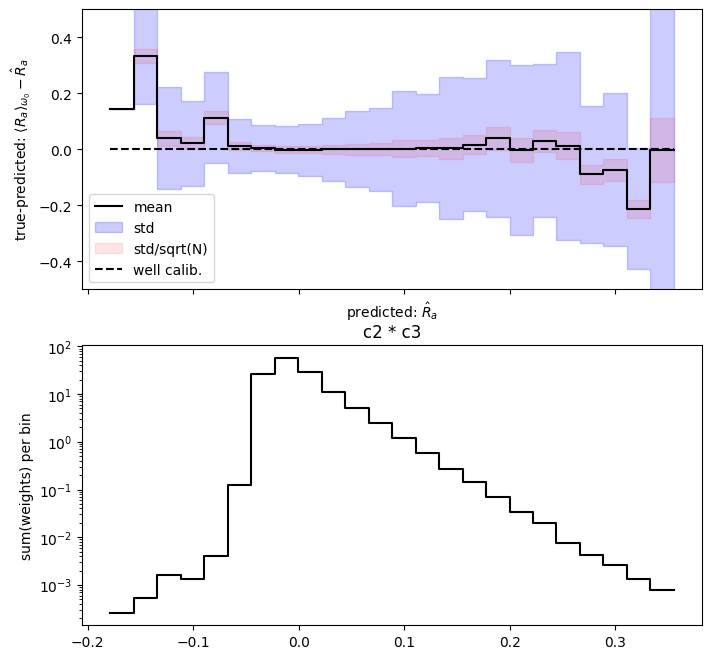

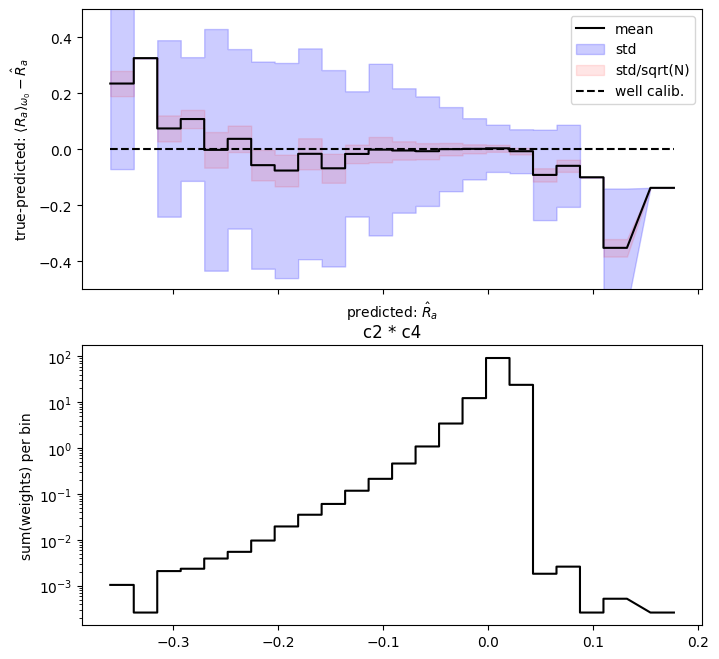

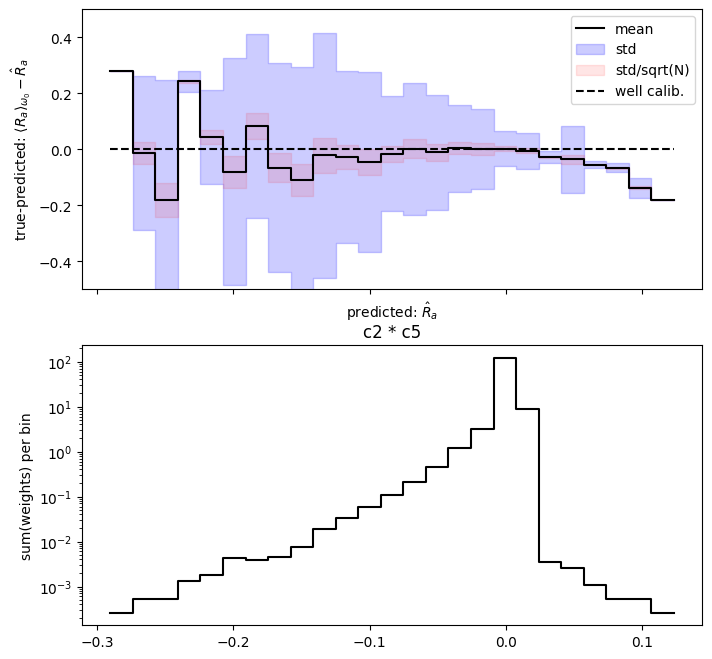

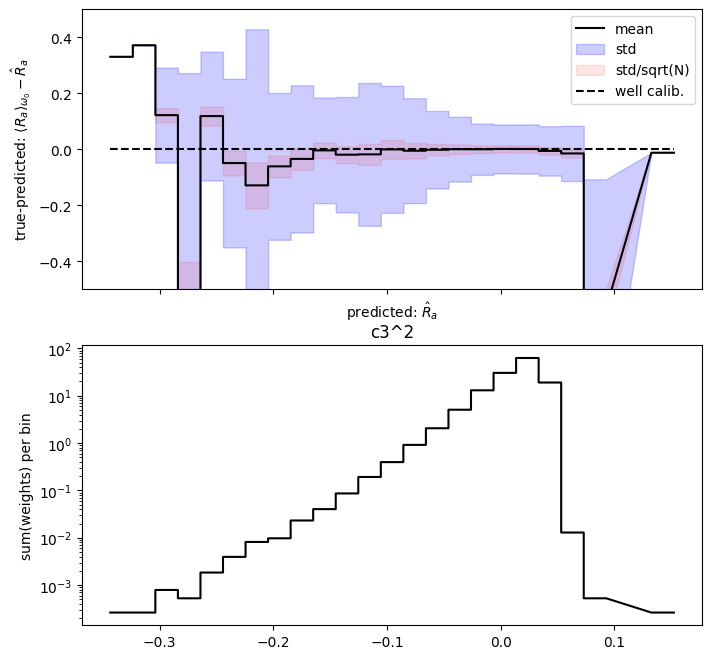

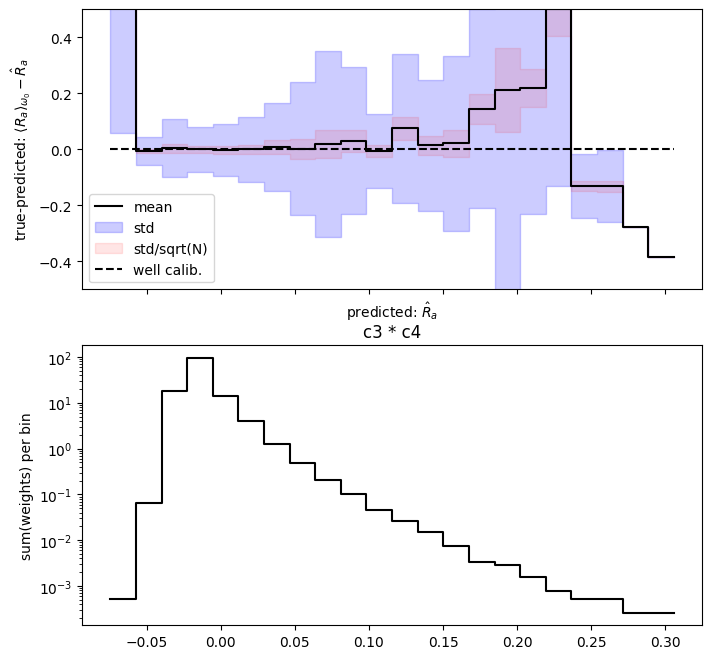

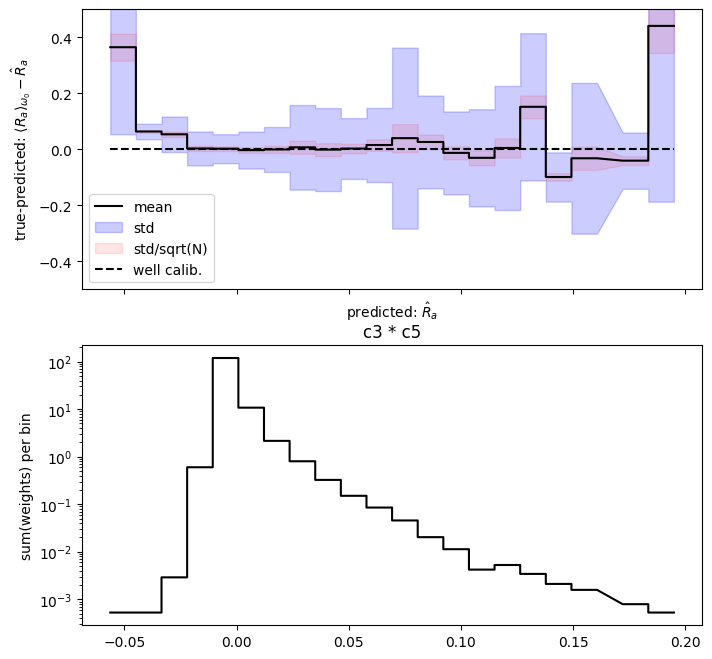

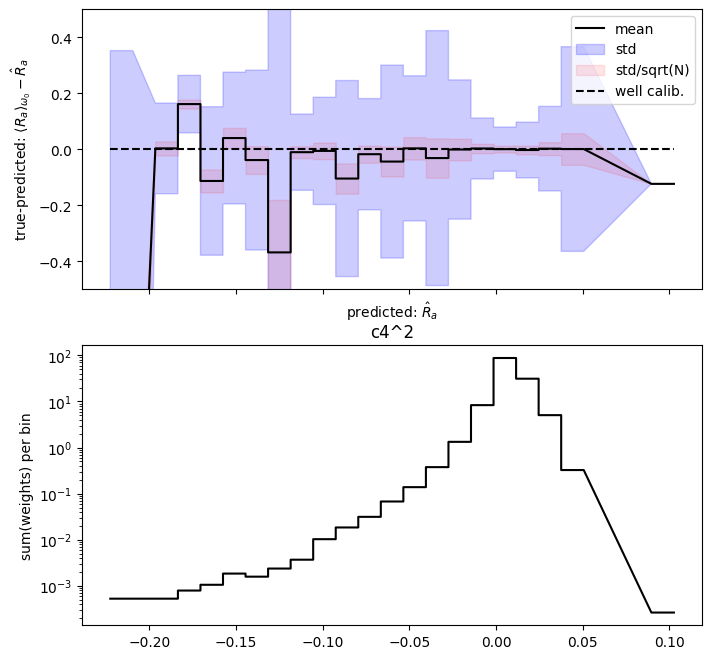

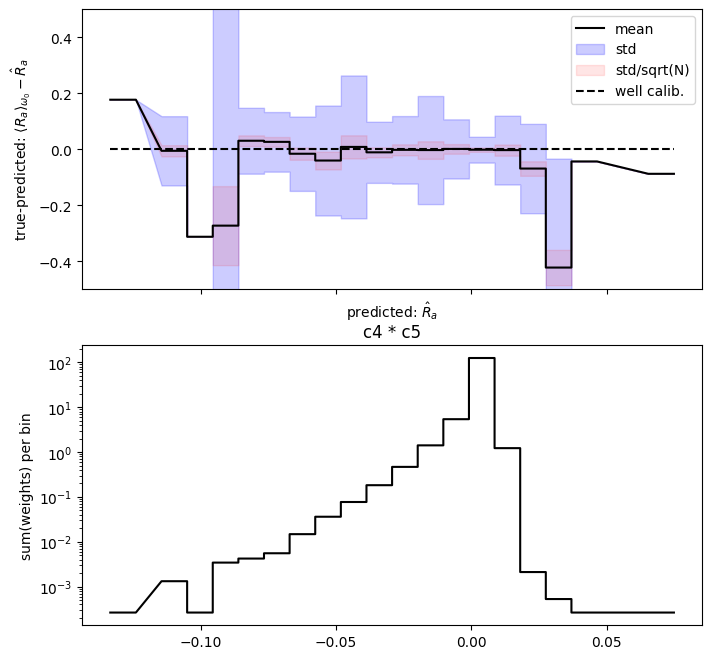

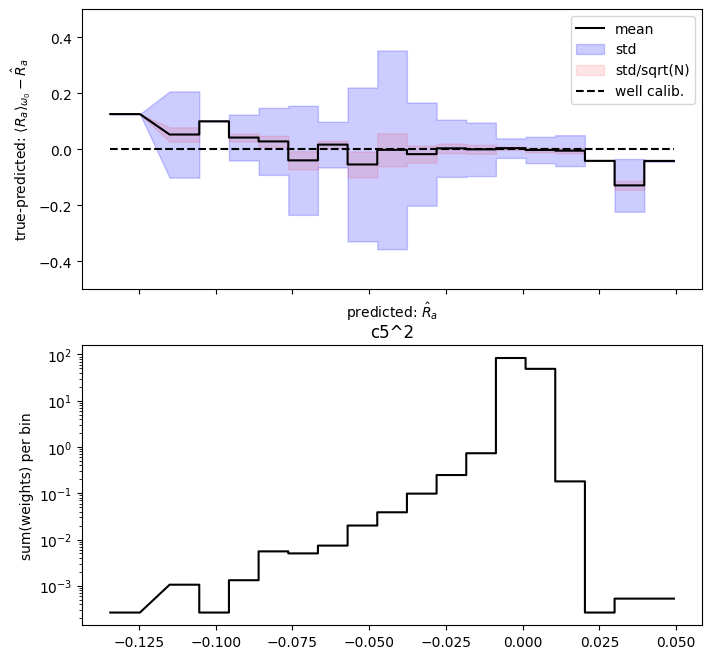

In [9]:
num_bins = 25

def counts_to_300fb(counts):
    ret = counts * (300./16.81)
    return ret

def fb_to_counts(fb):
    ret = fb * (16.81 / 300.)
    return ret

for idx, lab in enumerate(label):
    if lab in ['weight']:
        continue
    bins = np.linspace(pred_list[idx].min(),pred_list[idx].max(),num_bins+1)
    bin_centers = (bins[1:]+bins[:-1])*0.5
    
    which_bin = (pred_list[idx] > bins[:-1].reshape(-1,1)) & (pred_list[idx] <= bins[1:].reshape(-1,1))
    tmp_truth = []
    tmp_pred = []
    tmp_std = []
    tmp_count = []
    for i in range(num_bins):
        if len(pred_list[idx][which_bin[i]]) == 0:
            pass
        else:
            tmp_truth.append(weighted_mean(truth_list[idx][which_bin[i]], weights[which_bin[i]])-bin_centers[i])
            tmp_truth.append(weighted_mean(truth_list[idx][which_bin[i]], weights[which_bin[i]])-bin_centers[i])
            tmp_std.append(weighted_std(truth_list[idx][which_bin[i]], weights[which_bin[i]]))
            tmp_std.append(weighted_std(truth_list[idx][which_bin[i]], weights[which_bin[i]]))
            #tmp_pred.append(pred_list[idx][which_bin[i]].mean())
            tmp_pred.append(bins[i])
            tmp_pred.append(bins[i+1])
            #tmp_count.append(len(truth_list[idx][which_bin[i]]))
            #tmp_count.append(len(truth_list[idx][which_bin[i]]))
            tmp_count.append(np.sum(weights[which_bin[i]]))
            tmp_count.append(np.sum(weights[which_bin[i]]))
    tmp_truth = np.array(tmp_truth)
    tmp_pred = np.array(tmp_pred)
    tmp_std = np.array(tmp_std)
    
    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, sharex=True, figsize=(8, 8))
    
    ax_top.plot(tmp_pred, tmp_truth, color='k', label='mean')
    ax_top.fill_between(tmp_pred, tmp_truth+tmp_std,tmp_truth-tmp_std , color='b',alpha=0.2, label='std')
    ax_top.fill_between(tmp_pred, tmp_truth+tmp_std/np.sqrt(len(tmp_truth)),tmp_truth-tmp_std/np.sqrt(len(tmp_truth)) , color='r',alpha=0.1, label='std/sqrt(N)')
    ax_top.plot([tmp_pred.min(),tmp_pred.max()], [0.,0.], 'k--', label='well calib.')
    ax_top.set_xlabel(r'predicted: $\hat{R}_a$')
    ax_top.set_ylabel(r'true-predicted: $\langle R_a \rangle_{\omega_0} - \hat{R}_a$')
    ax_top.legend()
    ax_top.set_ylim(-0.5, 0.5)
    plt.title(label[idx])

    ax_bottom.plot(tmp_pred, tmp_count, color='k', label='mean')
    ax_bottom.set_yscale('log')
    ax_bottom.set_ylabel('sum(weights) per bin')
 
    plt.savefig(f"figures_delphes/nocalib_all_{lab}.png")
    plt.show()

In [8]:
# do a train / eval split
full_truth = truth_list.copy()
full_pred = pred_list.copy()
full_weights = weights.copy()

if False:
    split_at = 1_000_000
    truth_list, truth_list_eval = full_truth[:,:split_at], full_truth[:,split_at:]
    pred_list, pred_list_eval = full_pred[:,:split_at], full_pred[:,split_at:]
    weights, weights_eval = full_weights[:split_at], full_weights[split_at:]
elif True:
    truth_list_1, truth_list_2, truth_list_3 = full_truth[:,:500_000], full_truth[:,500_000:1_000_000],full_truth[:,1_000_000:]
    pred_list_1, pred_list_2, pred_list_3 = full_pred[:,:500_000], full_pred[:,500_000:1_000_000], full_pred[:,1_000_000:]
    weights_1, weights_2, weights_3 = full_weights[:500_000], full_weights[500_000:1_000_000], full_weights[1_000_000:]
else:
    pass

all_truths = [truth_list_1, truth_list_2, truth_list_3]
all_preds = [pred_list_1, pred_list_2, pred_list_3]
all_weights = [weights_1, weights_2, weights_3]

print(full_truth.shape, full_pred.shape, full_weights.shape)
print(truth_list_1.shape, pred_list_1.shape, weights_1.shape)
print(truth_list_2.shape, pred_list_2.shape, weights_2.shape)
print(truth_list_3.shape, pred_list_3.shape, weights_3.shape)


(27, 104998) (27, 104998) (104998,)
(27, 104998) (27, 104998) (104998,)
(27, 0) (27, 0) (0,)
(27, 0) (27, 0) (0,)


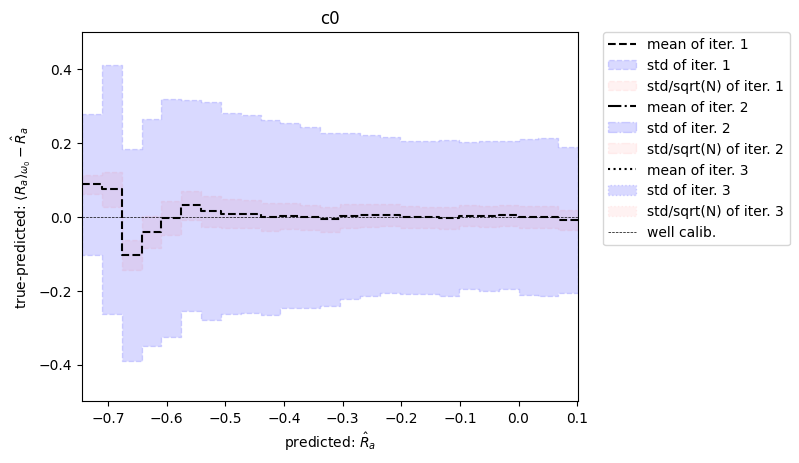

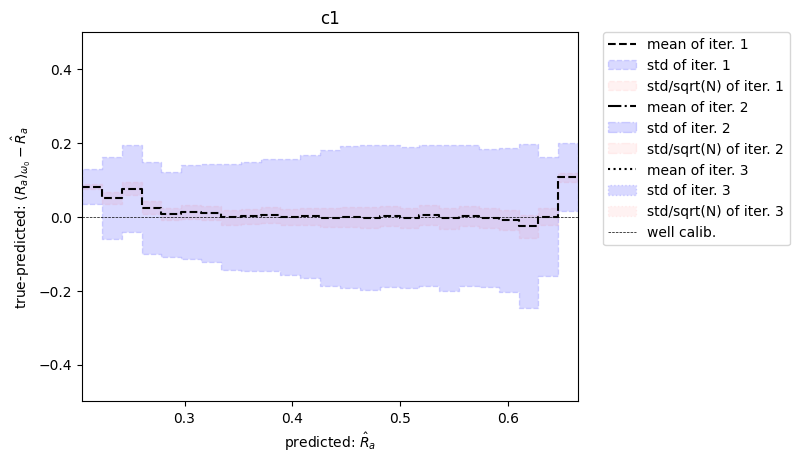

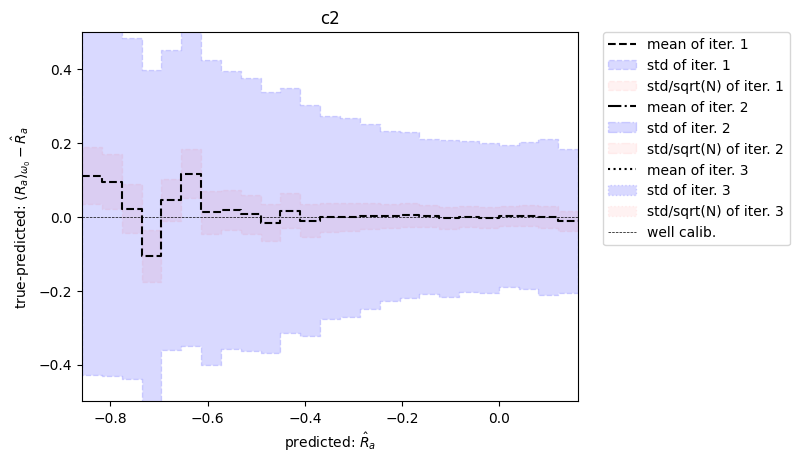

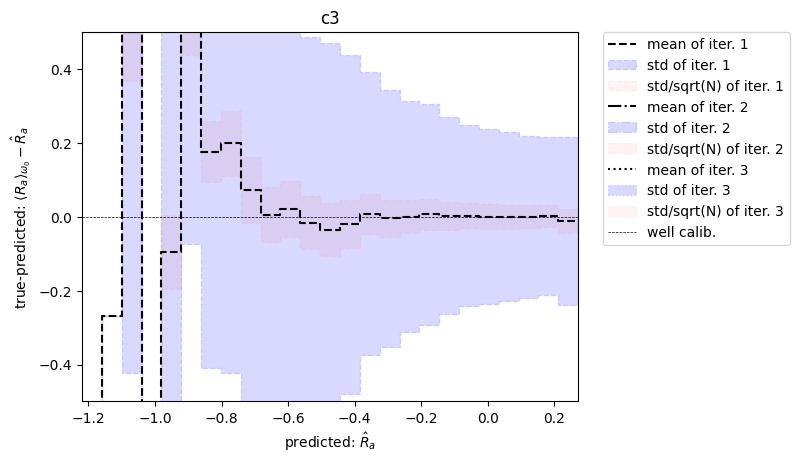

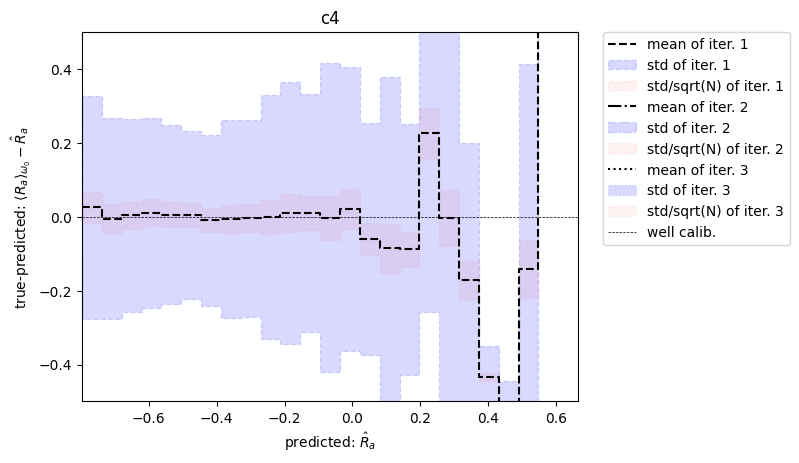

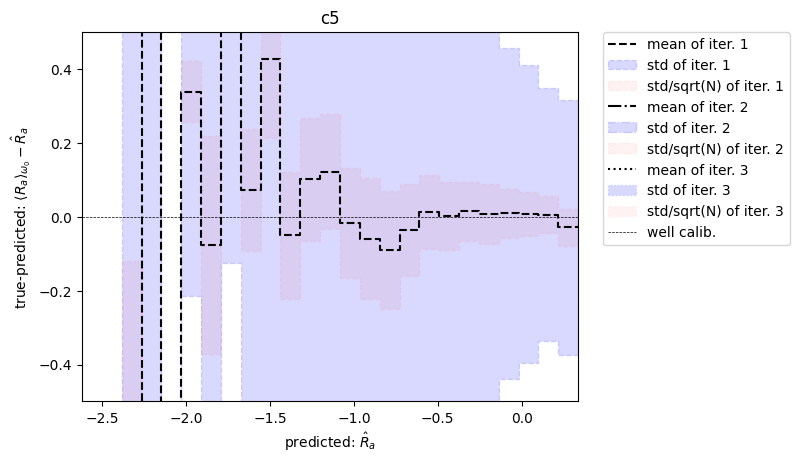

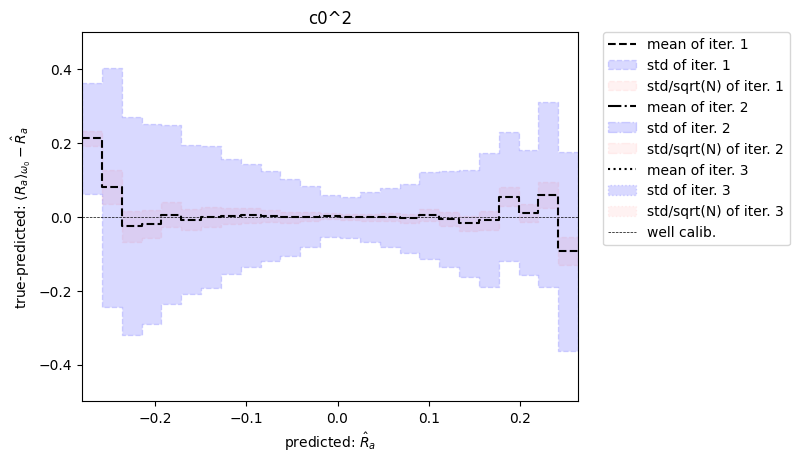

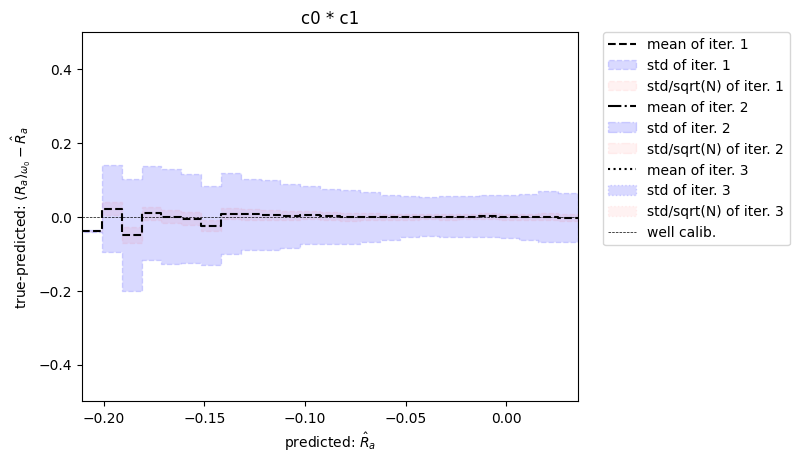

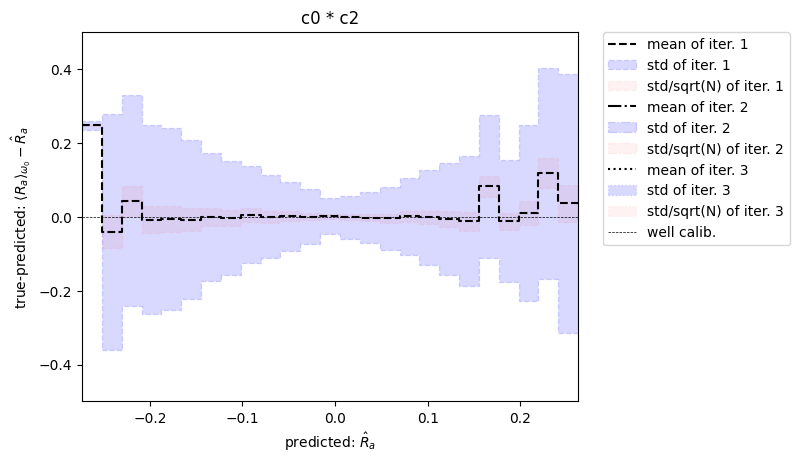

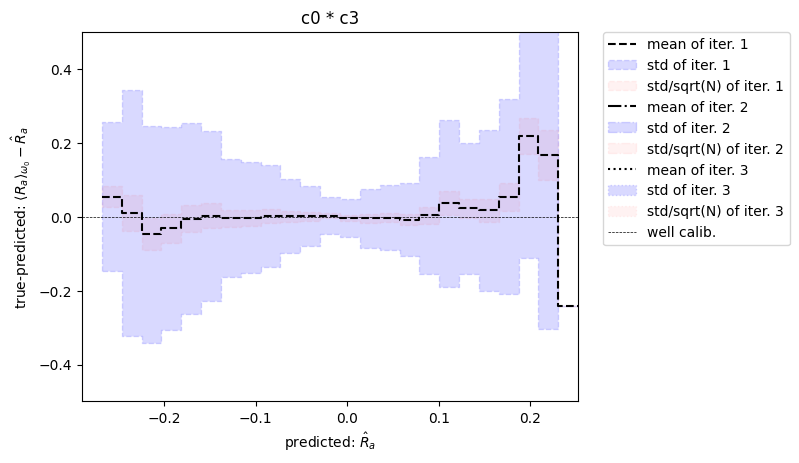

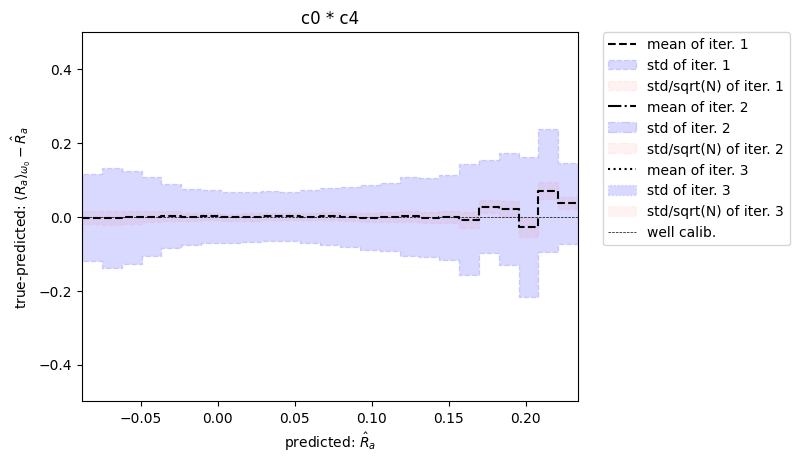

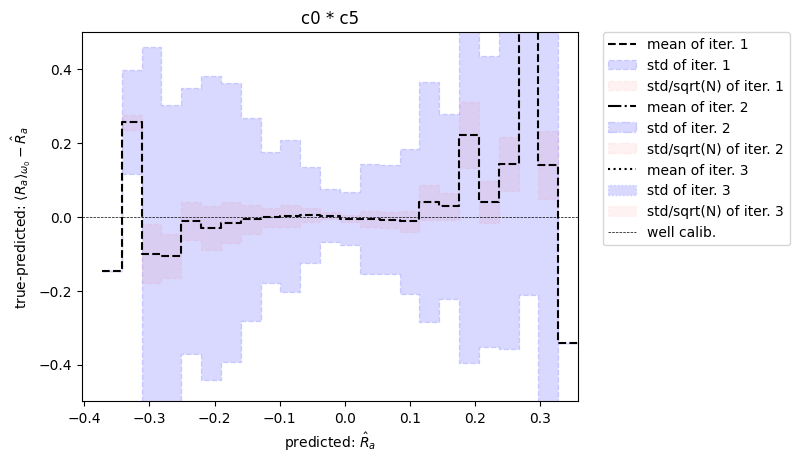

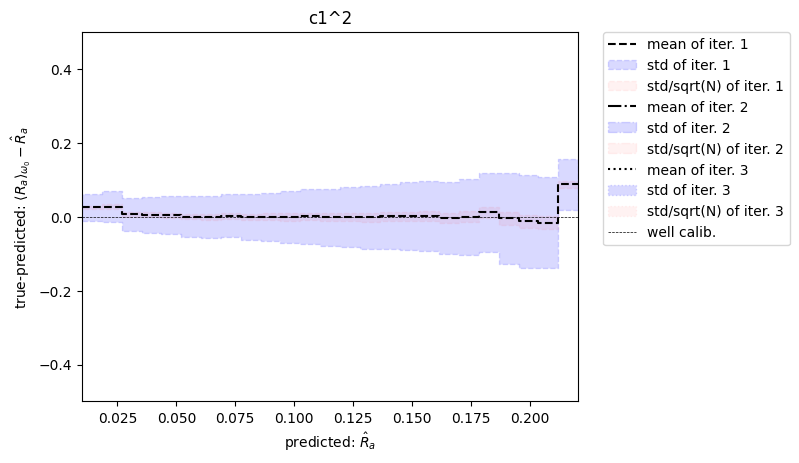

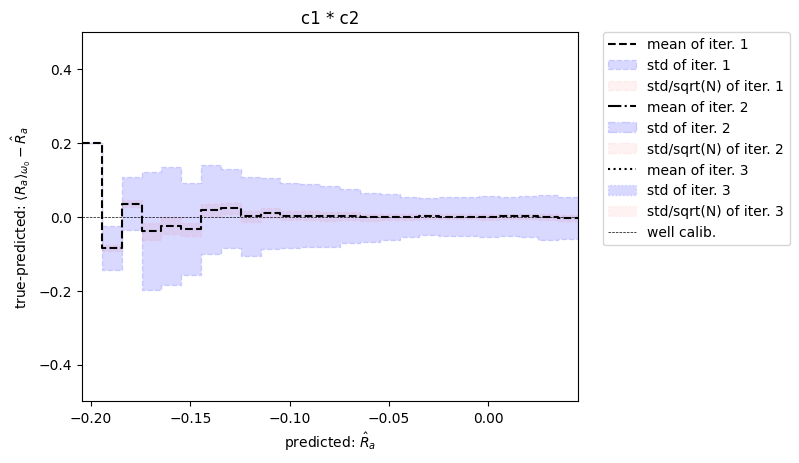

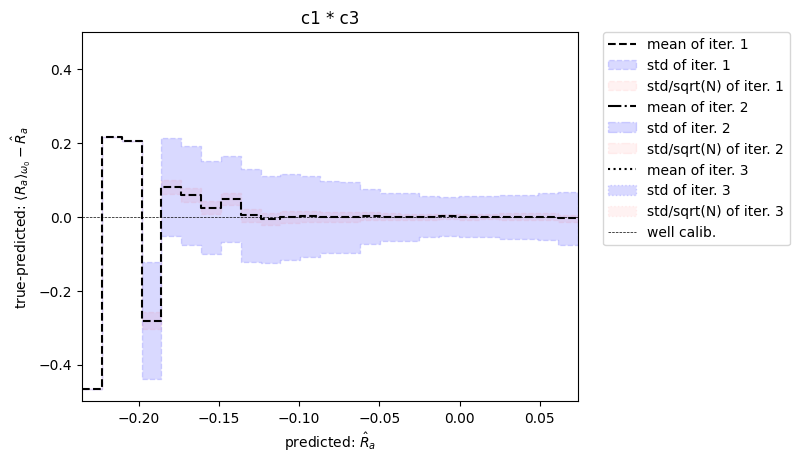

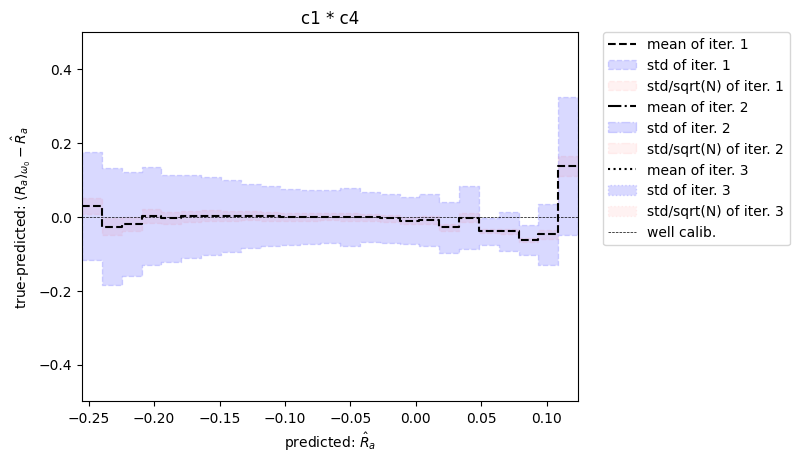

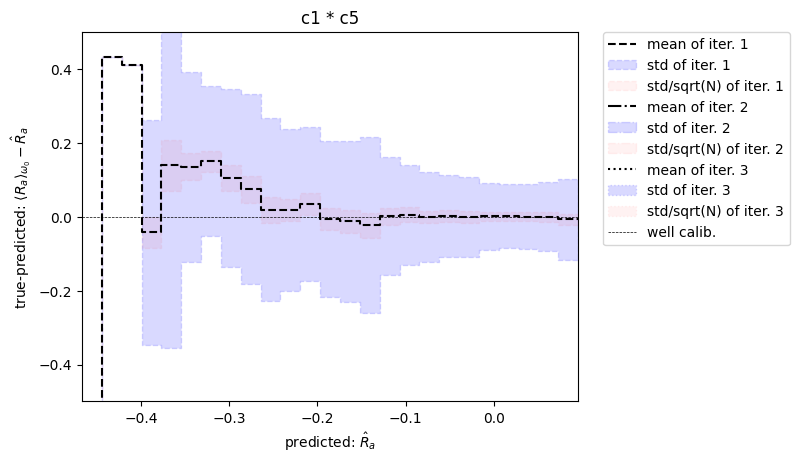

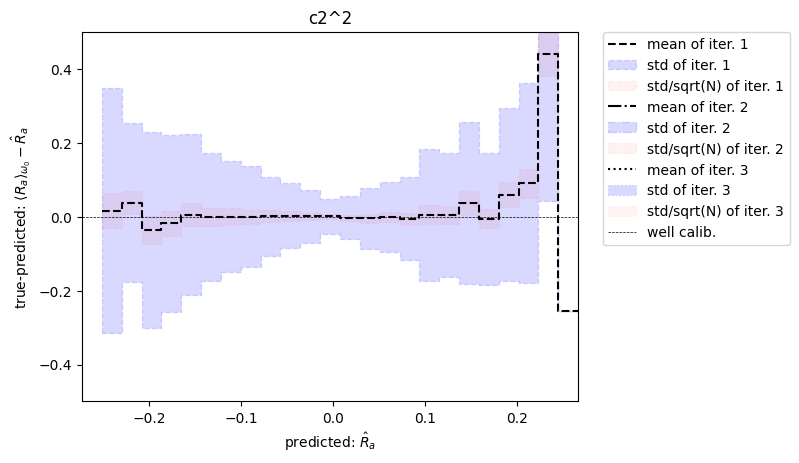

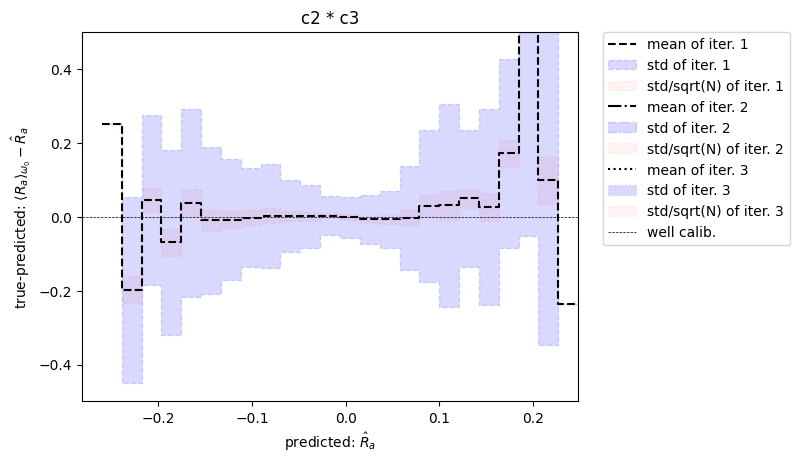

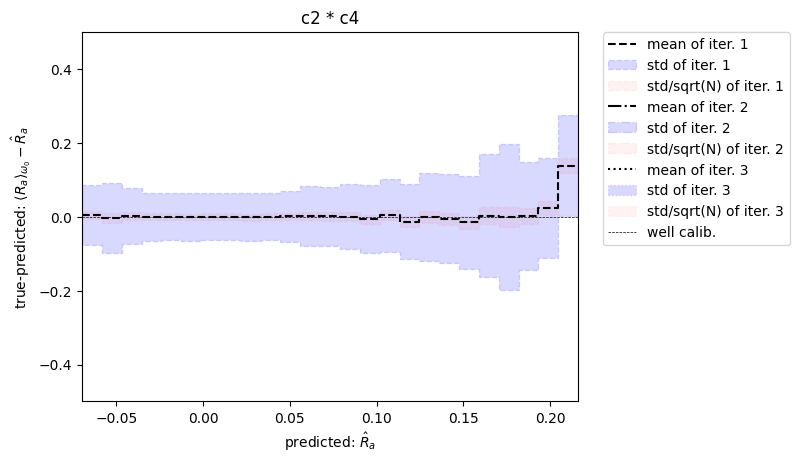

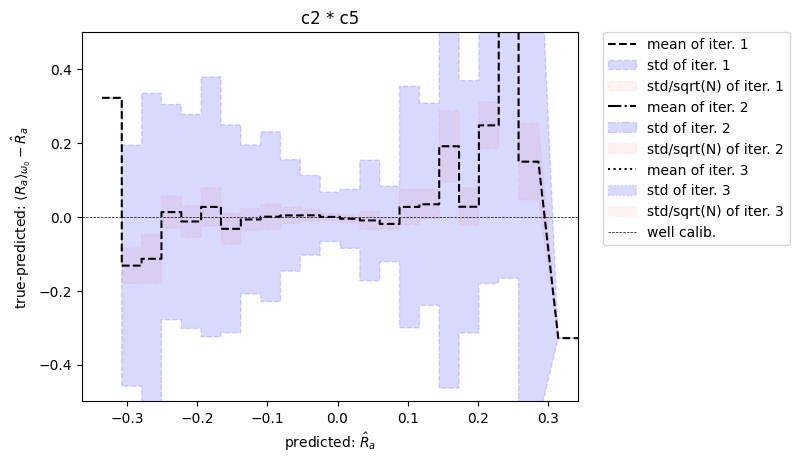

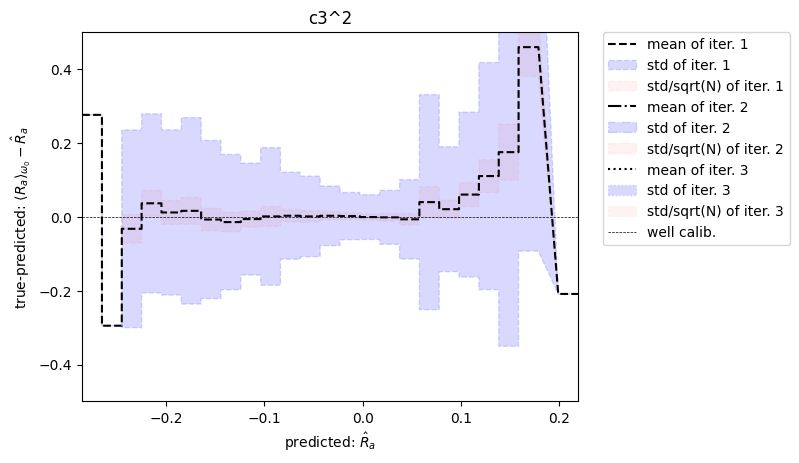

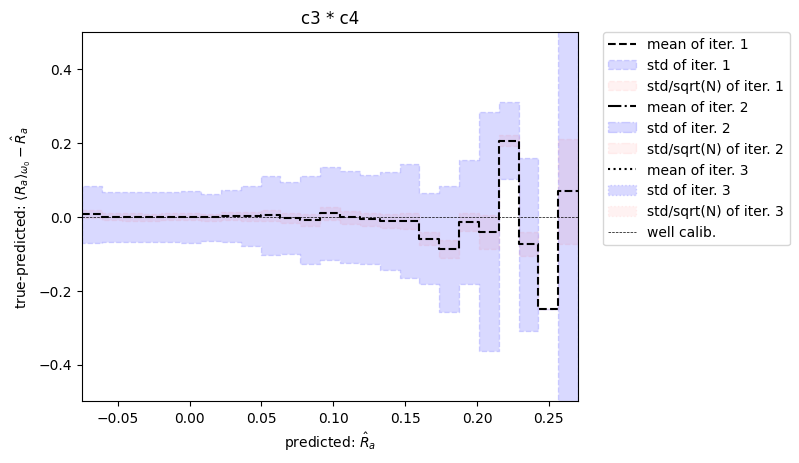

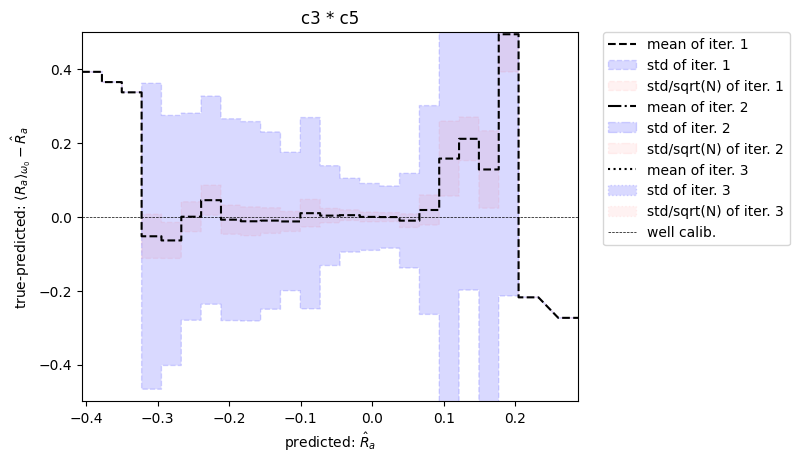

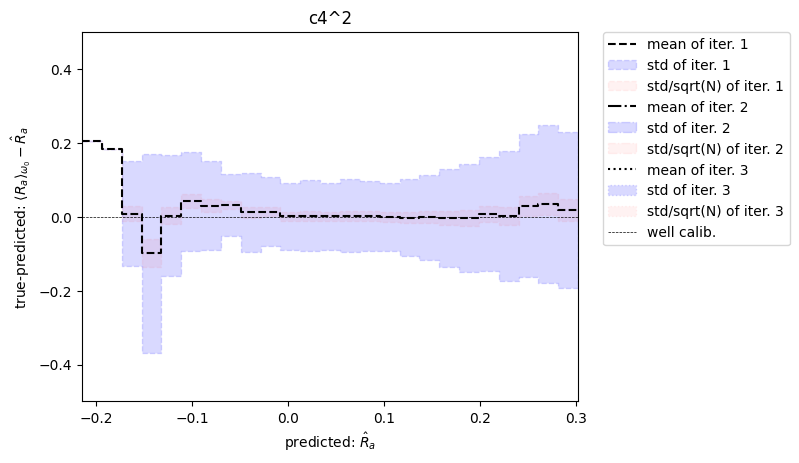

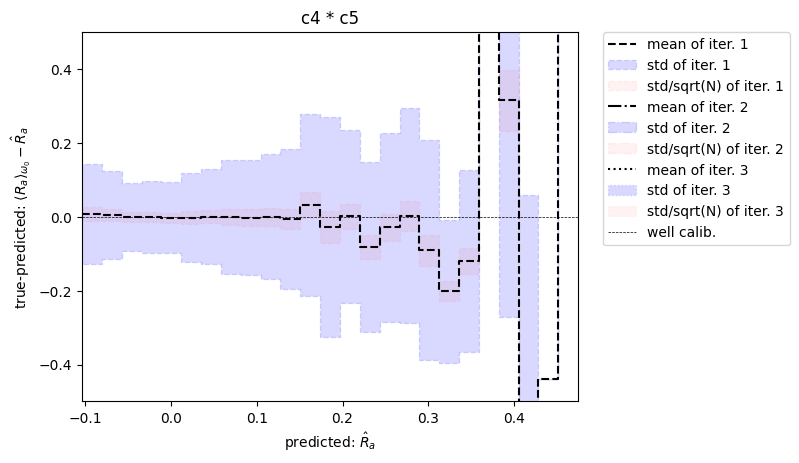

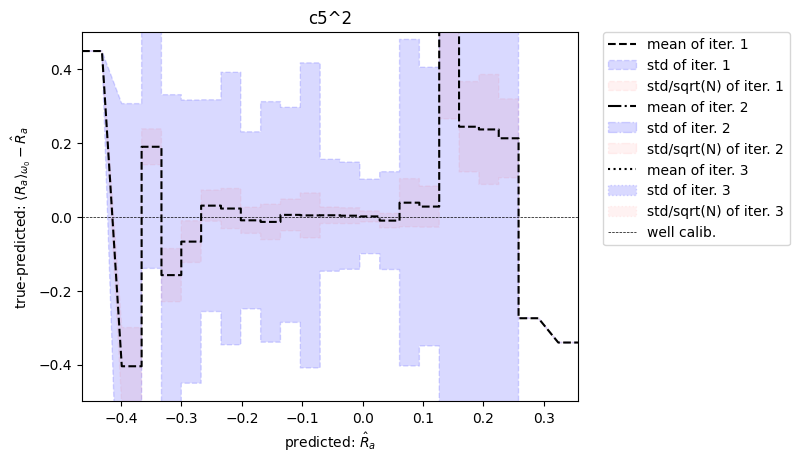

In [9]:
# redo plots of the 3 thirds to compare them. 
num_bins = 25

styles = ['dashed', 'dashdot', 'dotted']

for idx, lab in enumerate(label):
    if lab in ['weight']:
        continue
    for iteration in range(3):
        bins = np.linspace(full_pred[idx].min(),full_pred[idx].max(),num_bins+1)
        bin_centers = (bins[1:]+bins[:-1])*0.5
    
        which_bin = (all_preds[iteration][idx] > bins[:-1].reshape(-1,1)) & (all_preds[iteration][idx] <= bins[1:].reshape(-1,1))
        tmp_truth = []
        tmp_pred = []
        tmp_std = []
        for i in range(num_bins):
            if len(all_preds[iteration][idx][which_bin[i]]) == 0:
                pass
            else:
                tmp_truth.append(weighted_mean(all_truths[iteration][idx][which_bin[i]], all_weights[iteration][which_bin[i]])-bin_centers[i])
                tmp_truth.append(weighted_mean(all_truths[iteration][idx][which_bin[i]], all_weights[iteration][which_bin[i]])-bin_centers[i])
                tmp_std.append(weighted_std(all_truths[iteration][idx][which_bin[i]], all_weights[iteration][which_bin[i]]))
                tmp_std.append(weighted_std(all_truths[iteration][idx][which_bin[i]], all_weights[iteration][which_bin[i]]))
                tmp_pred.append(bins[i])
                tmp_pred.append(bins[i+1])
        tmp_truth = np.array(tmp_truth)
        tmp_pred = np.array(tmp_pred)
        tmp_std = np.array(tmp_std)
        plt.plot(tmp_pred, tmp_truth, color='k', label=f'mean of iter. {iteration+1}', linestyle=styles[iteration])
        plt.fill_between(tmp_pred, tmp_truth+tmp_std,tmp_truth-tmp_std , color='b',alpha=0.15, label=f'std of iter. {iteration+1}', linestyle=styles[iteration])
        plt.fill_between(tmp_pred, tmp_truth+tmp_std/np.sqrt(len(tmp_truth)),tmp_truth-tmp_std/np.sqrt(len(tmp_truth)) , color='r',alpha=0.05, 
                         label=f'std/sqrt(N) of iter. {iteration+1}', linestyle=styles[iteration])
    plt.plot([bins[0],bins[-1]], [0.,0.], 'k--', label='well calib.', linewidth=0.5)
    plt.xlabel(r'predicted: $\hat{R}_a$')
    plt.ylabel(r'true-predicted: $\langle R_a \rangle_{\omega_0} - \hat{R}_a$')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.ylim(-0.5, 0.5)
    plt.xlim(bins[0],bins[-1])
    plt.title(label[idx])
    plt.savefig(f"figures/nocalib_thirds_{lab}.png")
    plt.show()

In [10]:
# train an iso_reg on train set
from sklearn.isotonic import IsotonicRegression
iso_reg = []


for idx, lab in enumerate(label):
    if lab in ['weight']:
        continue
    iso_reg.append(IsotonicRegression(out_of_bounds='clip').fit(pred_list[idx], truth_list[idx]))

In [11]:
# plot residuals with and without iso reg
for idx, lab in enumerate(label):
    if lab in ['weight']:
        continue
    pred_list_calib = iso_reg[idx].predict(pred_list_eval[idx])
    bins = np.linspace(pred_list_calib.min(),pred_list_calib.max(),num_bins+1)
    bin_centers = (bins[1:]+bins[:-1])*0.5
    
    which_bin = (pred_list_calib > bins[:-1].reshape(-1,1)) & (pred_list_calib <= bins[1:].reshape(-1,1))
    tmp_truth = []
    tmp_pred = []
    tmp_std = []
    for i in range(num_bins):
        if len(pred_list_calib[which_bin[i]]) == 0:
            pass
        else:
            tmp_truth.append(weighted_mean(truth_list_eval[idx][which_bin[i]], weights_eval[which_bin[i]])-bin_centers[i])
            tmp_truth.append(weighted_mean(truth_list_eval[idx][which_bin[i]], weights_eval[which_bin[i]])-bin_centers[i])
            tmp_std.append(weighted_std(truth_list_eval[idx][which_bin[i]], weights_eval[which_bin[i]]))
            tmp_std.append(weighted_std(truth_list_eval[idx][which_bin[i]], weights_eval[which_bin[i]]))
            tmp_pred.append(bins[i])
            tmp_pred.append(bins[i+1])
    tmp_truth = np.array(tmp_truth)
    tmp_pred = np.array(tmp_pred)
    tmp_std = np.array(tmp_std)
    plt.plot(tmp_pred, tmp_truth, color='k', label='calib. mean')
    plt.fill_between(tmp_pred, tmp_truth+tmp_std,tmp_truth-tmp_std , color='b',alpha=0.2, label='calib. std')
    plt.fill_between(tmp_pred, tmp_truth+tmp_std/np.sqrt(len(tmp_truth)),tmp_truth-tmp_std/np.sqrt(len(tmp_truth)) , color='r',alpha=0.1, label='calib. std/sqrt(N)')
    plt.plot([tmp_pred.min(),tmp_pred.max()], [0.,0.], 'k--', label='well calib.')
    plt.xlabel(r'predicted: $\hat{R}_a$')
    plt.ylabel(r'true-predicted: $\langle R_a \rangle_{\omega_0} - \hat{R}_a$')
    plt.legend()
    plt.ylim(-0.5, 0.5)
    plt.title(label[idx])
    plt.savefig(f"figures/calib_{lab}.png")
    plt.show()

NameError: name 'pred_list_eval' is not defined

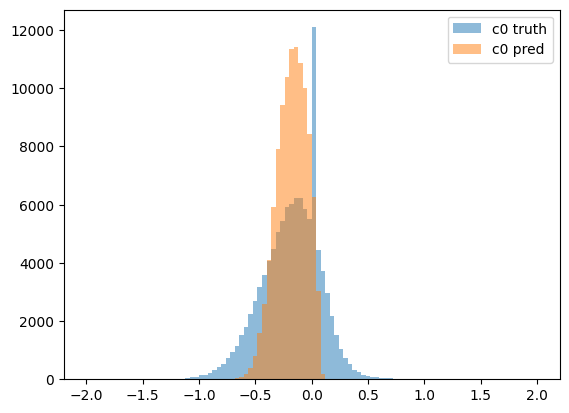

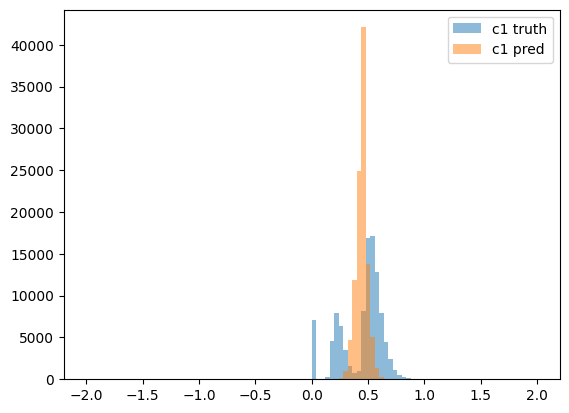

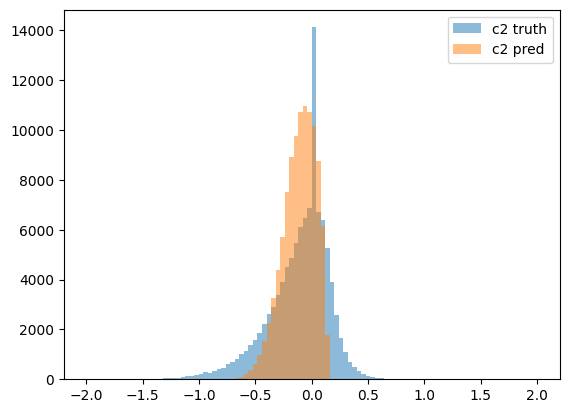

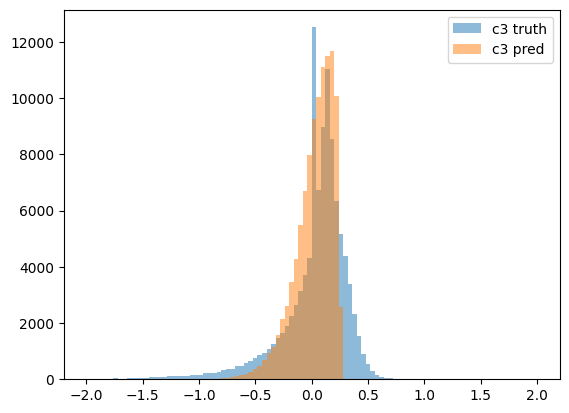

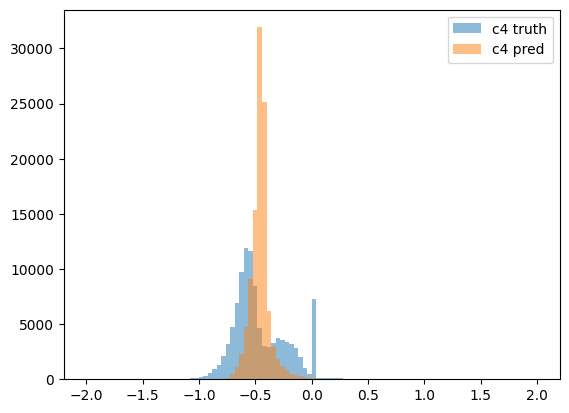

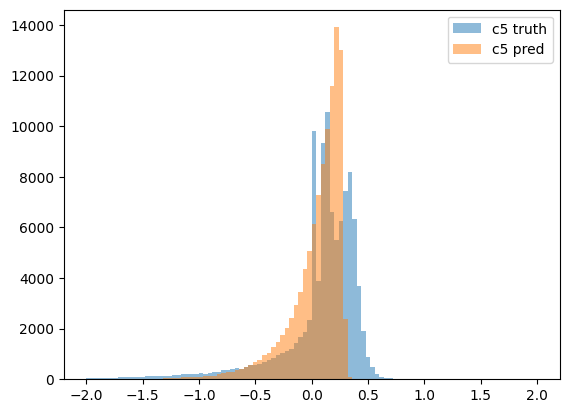

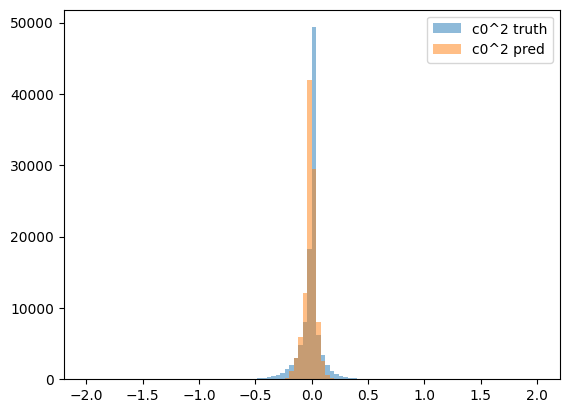

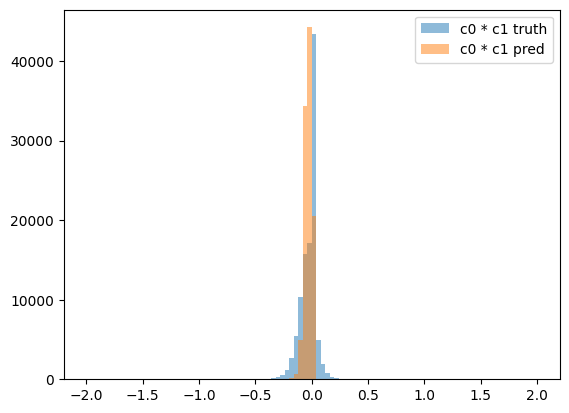

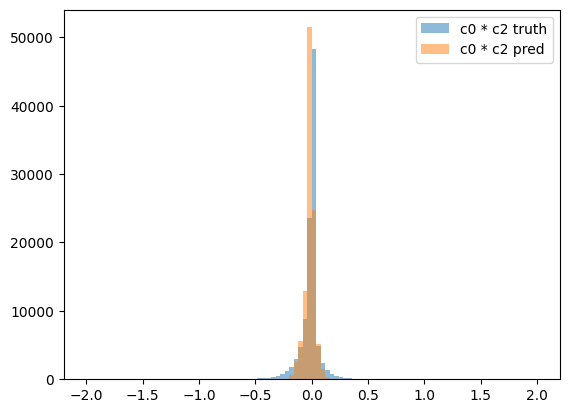

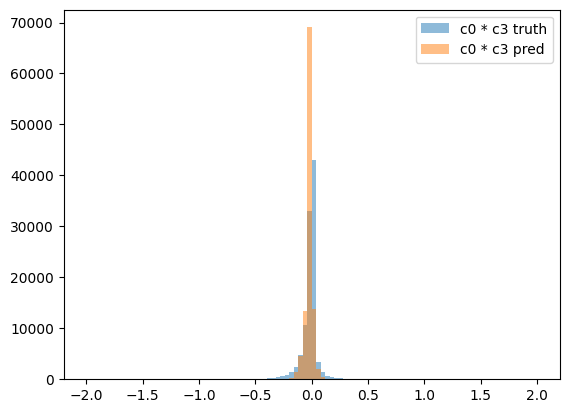

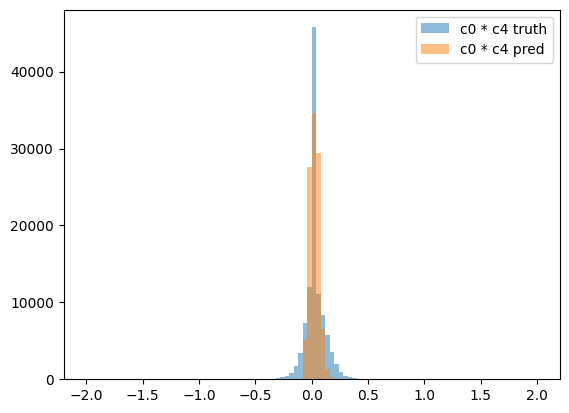

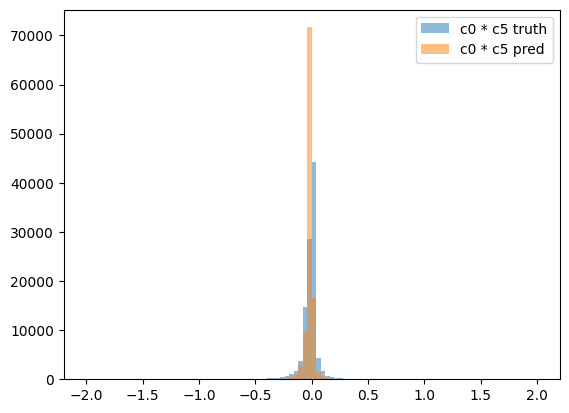

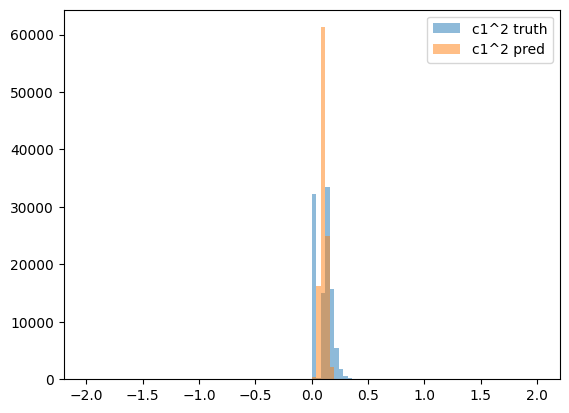

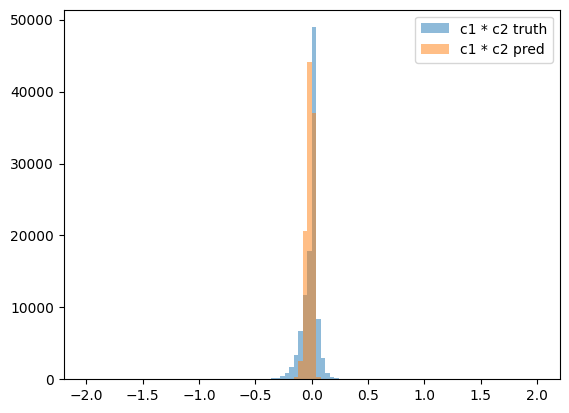

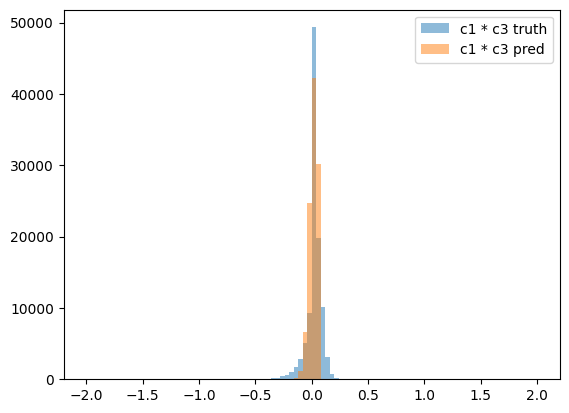

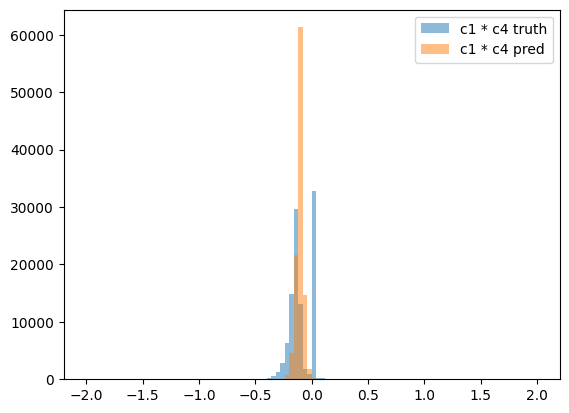

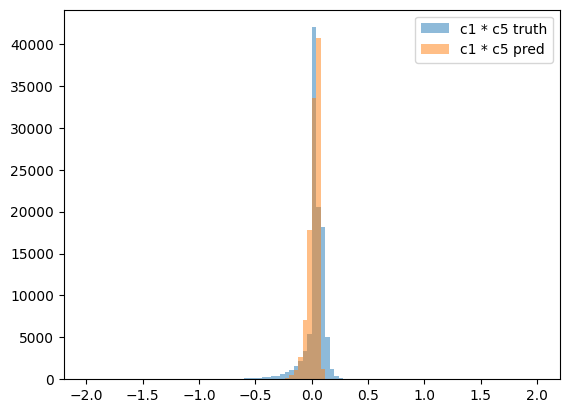

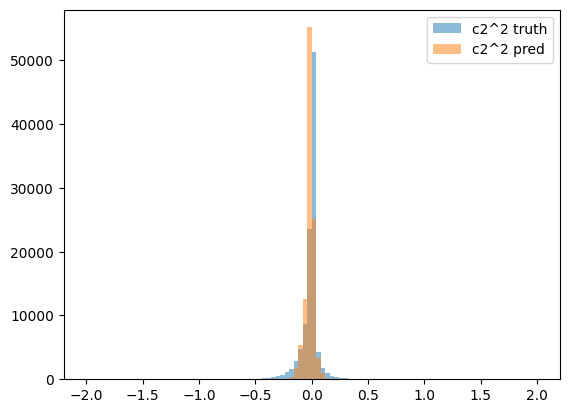

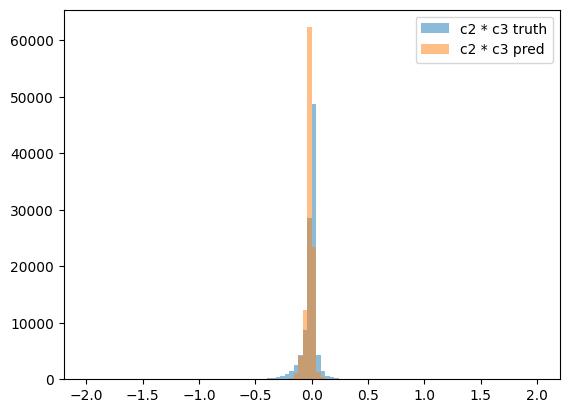

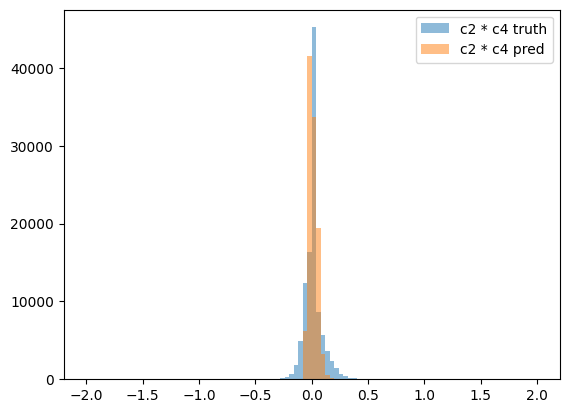

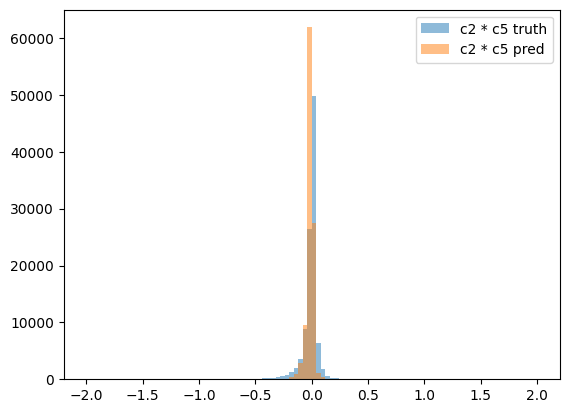

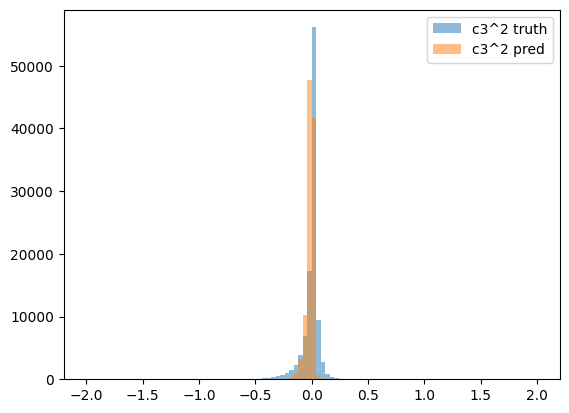

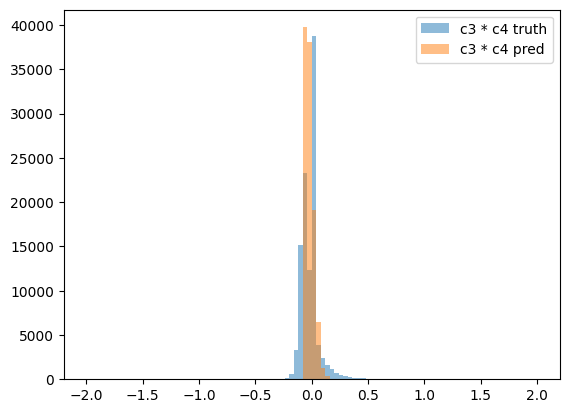

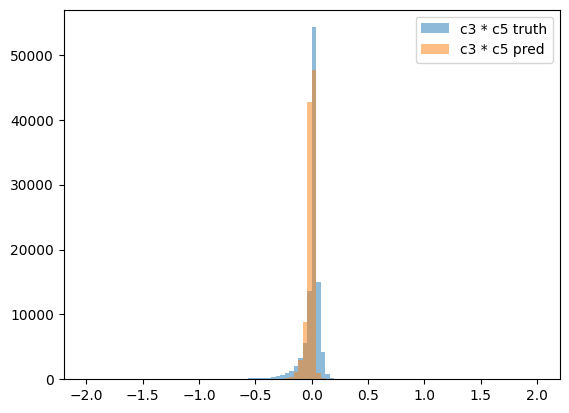

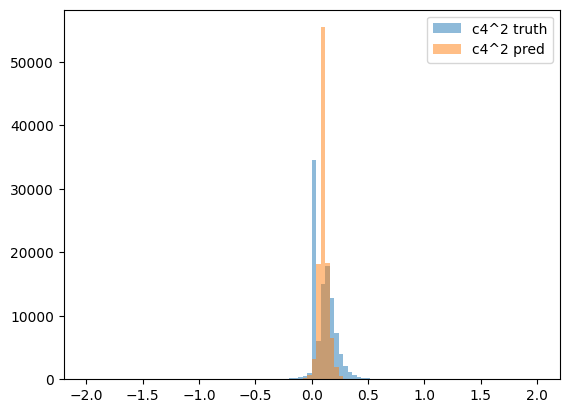

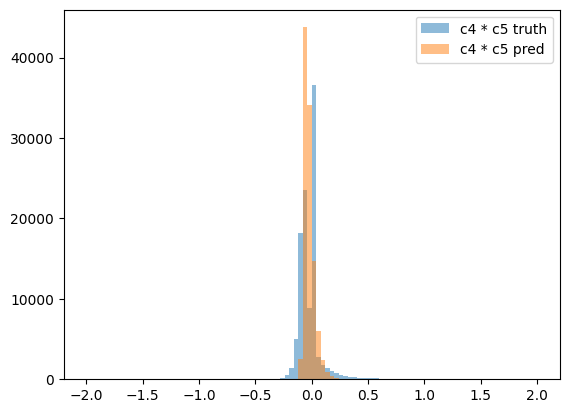

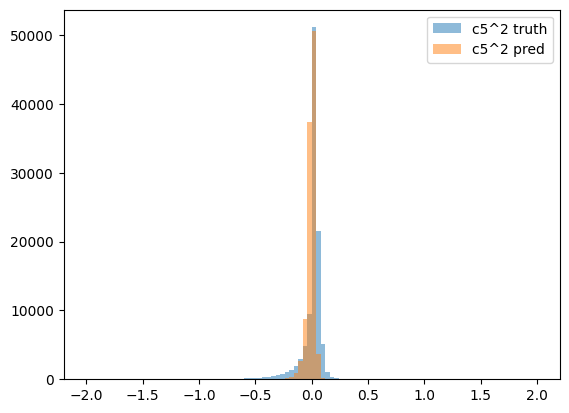

IndexError: index 27 is out of bounds for axis 0 with size 27

In [12]:
bins = np.linspace(-2,2,101)
for idx, lab in enumerate(label):
    plt.hist(truth_list[idx], label=f"{lab} truth", bins=bins, alpha=0.5)
    plt.hist(pred_list[idx], label=f"{lab} pred", bins=bins, alpha=0.5)
    plt.legend()
    plt.show()

[-2.  -1.8 -1.6 -1.4 -1.2 -1.  -0.8 -0.6 -0.4 -0.2  0.   0.2  0.4  0.6
  0.8  1.   1.2  1.4  1.6  1.8  2. ]


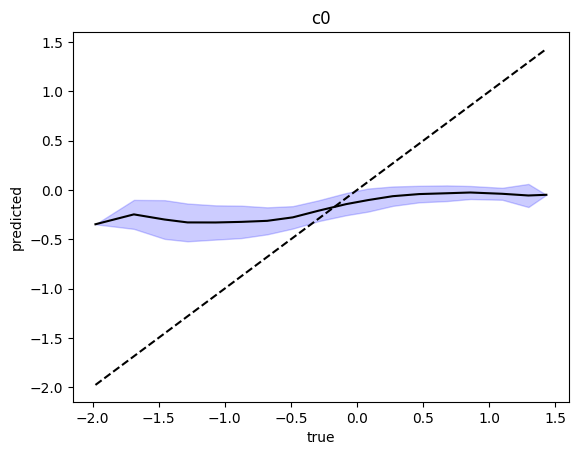

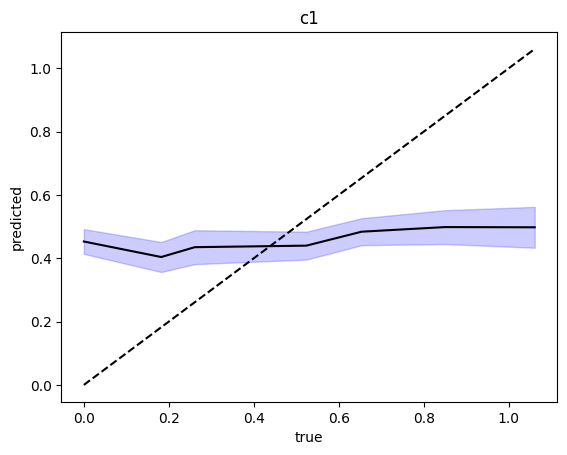

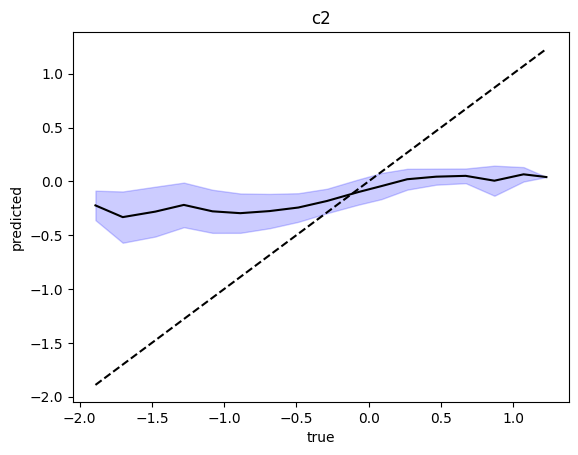

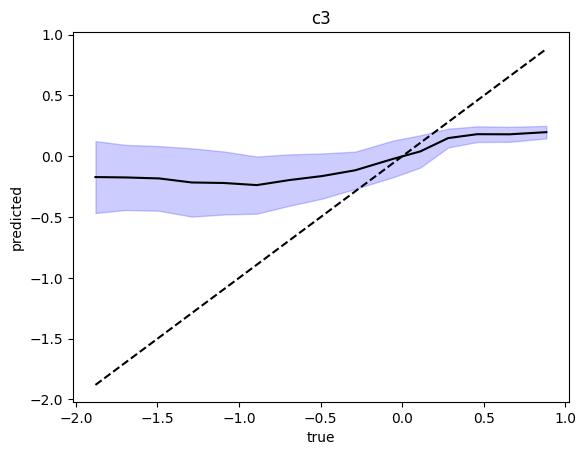

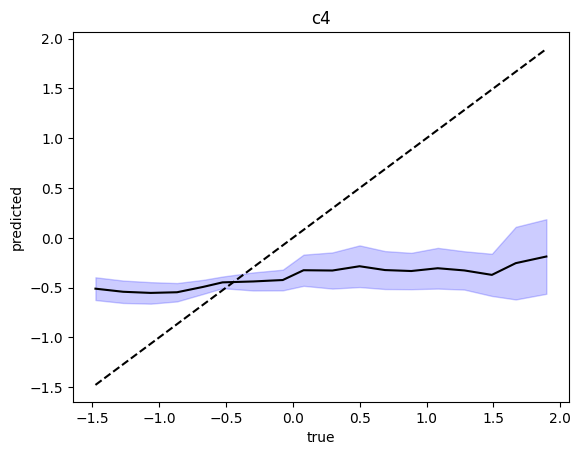

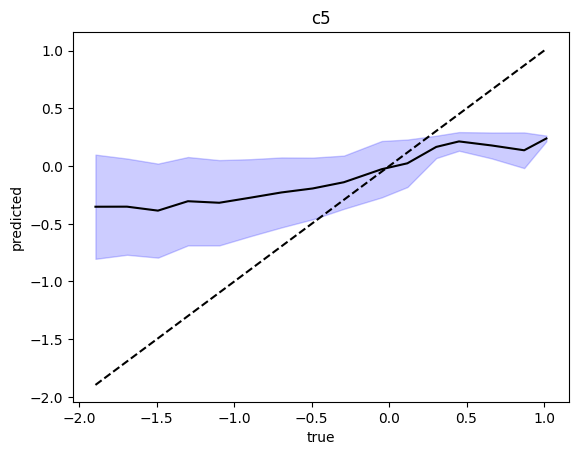

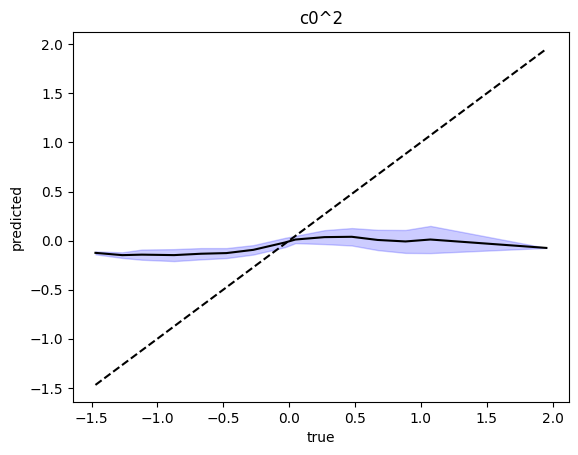

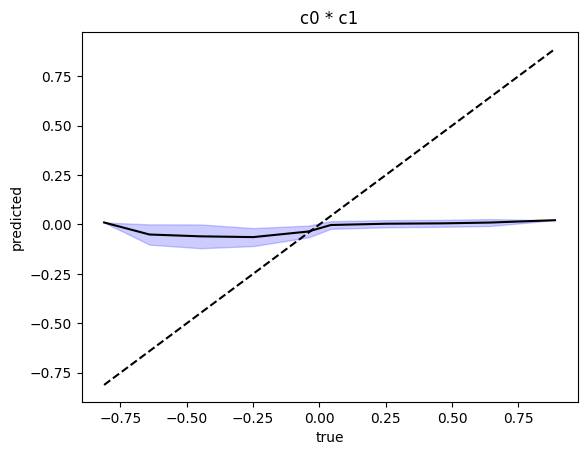

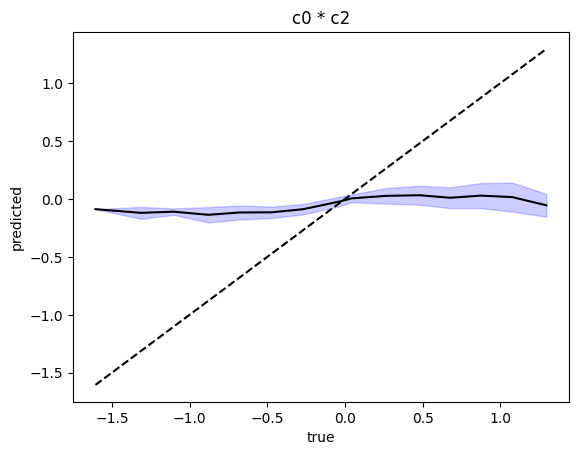

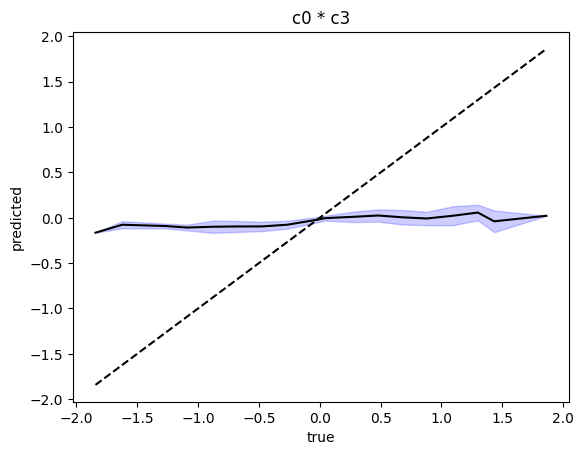

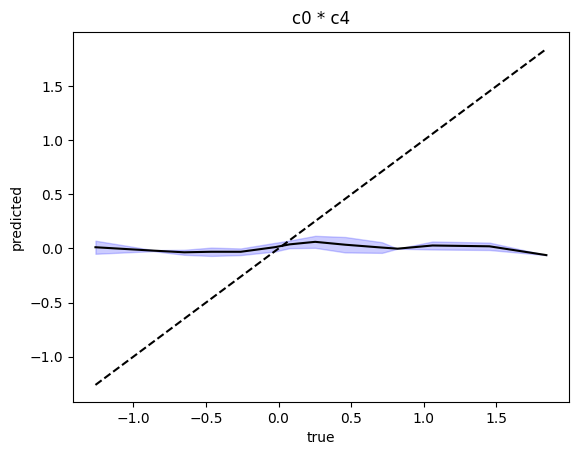

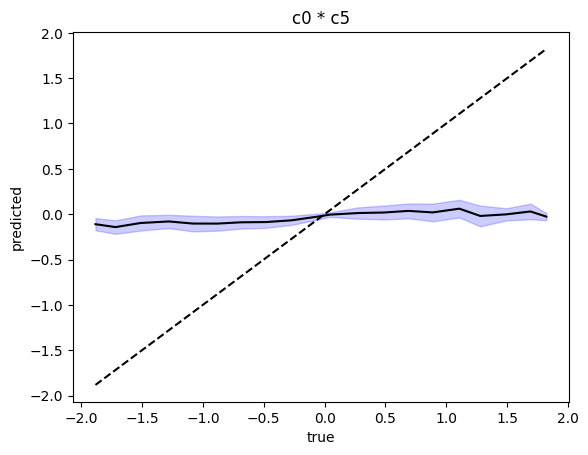

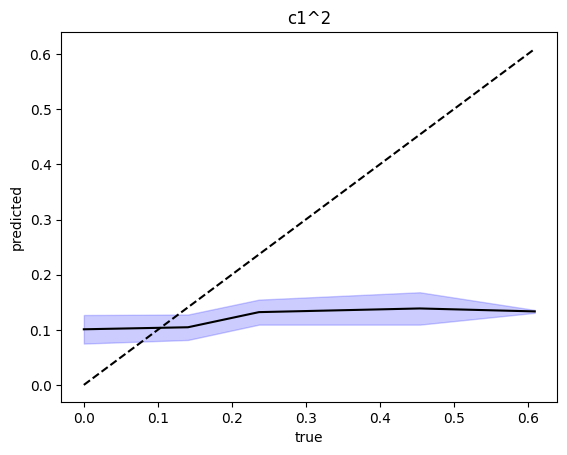

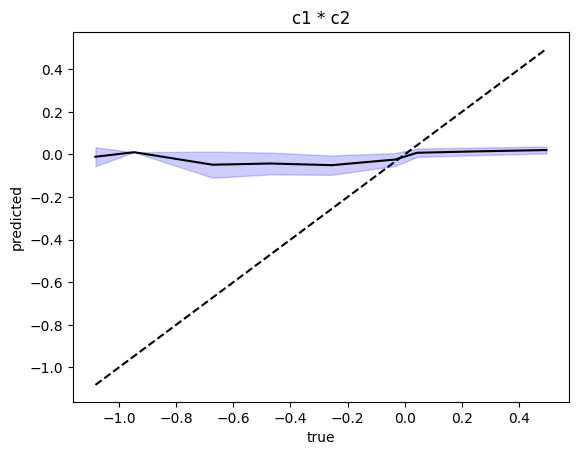

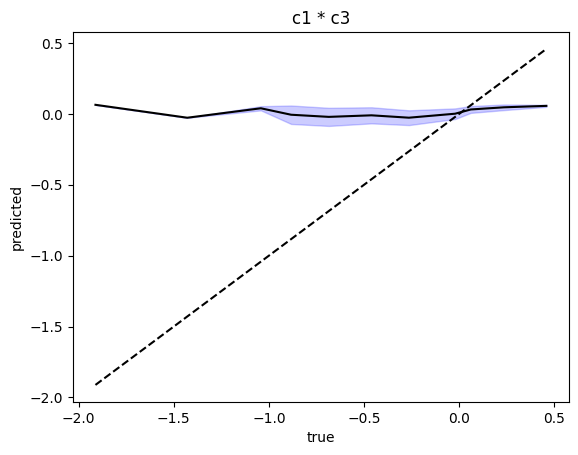

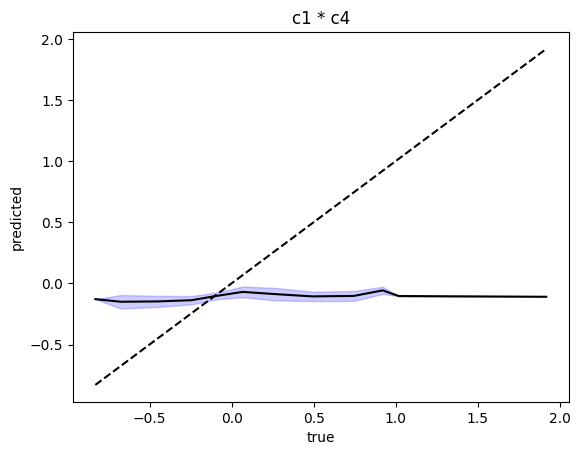

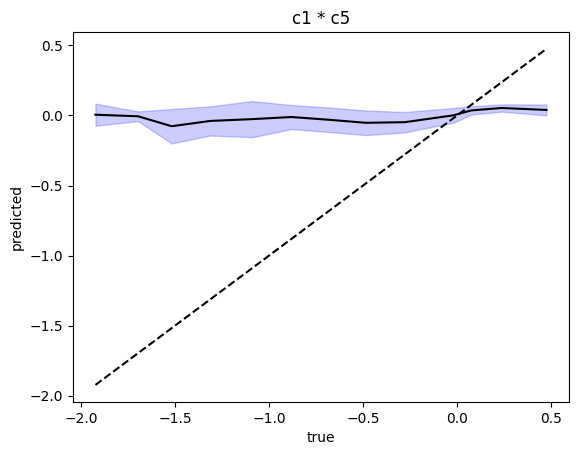

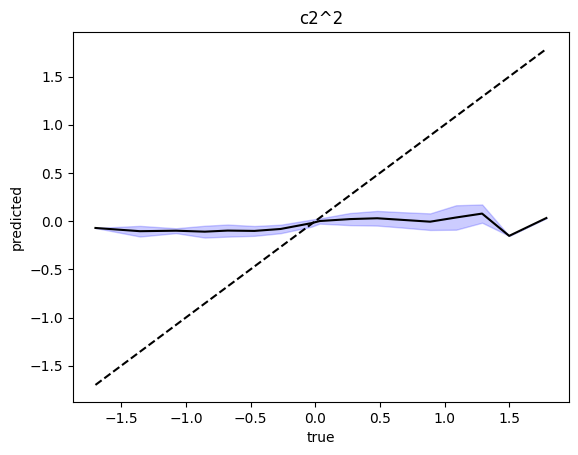

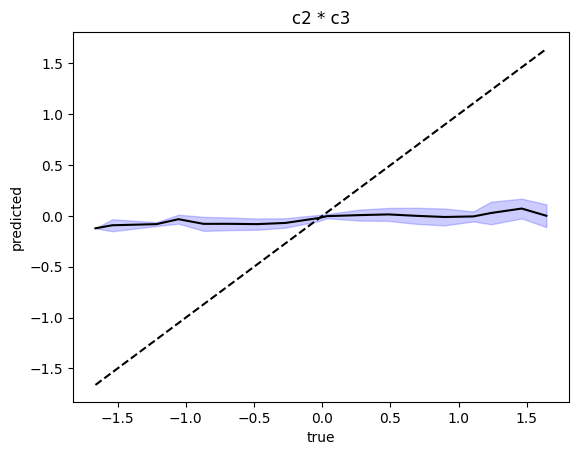

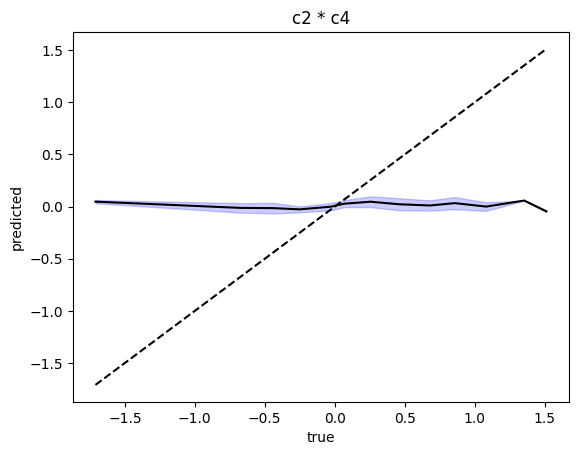

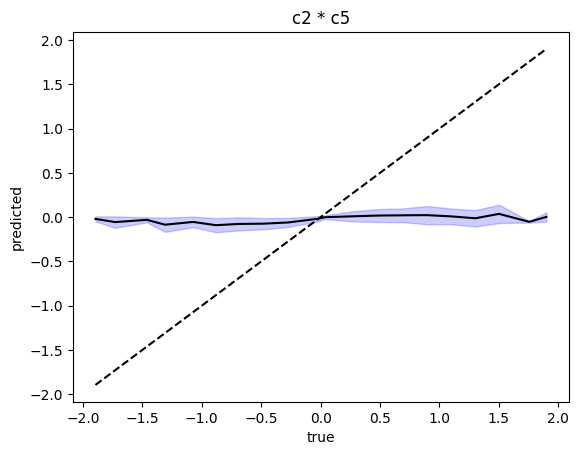

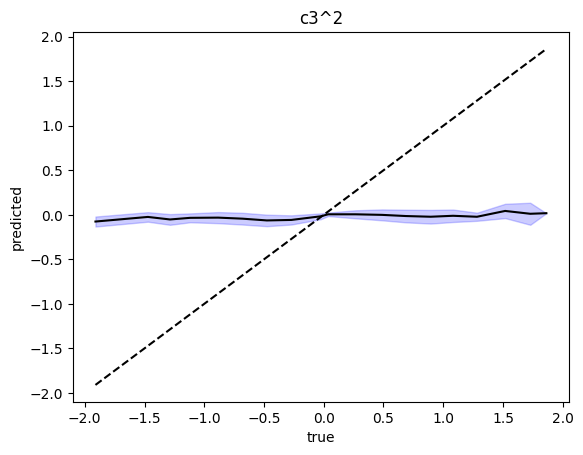

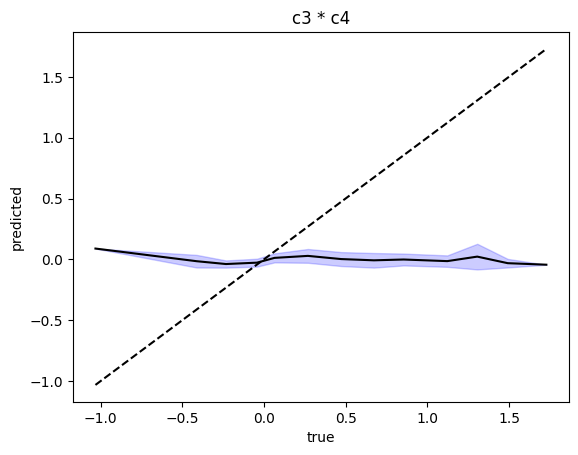

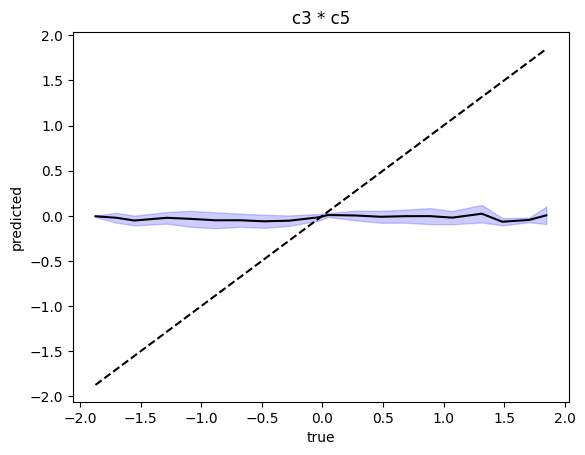

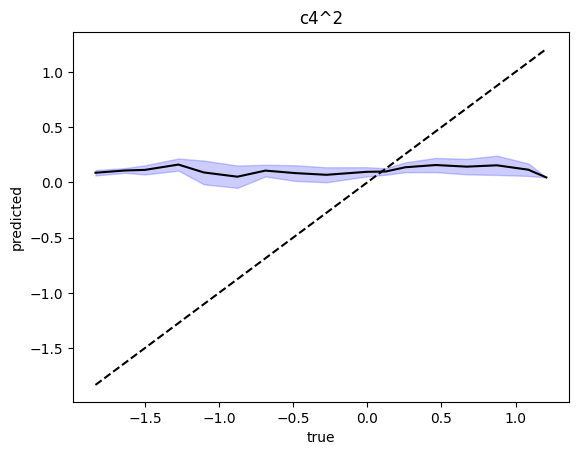

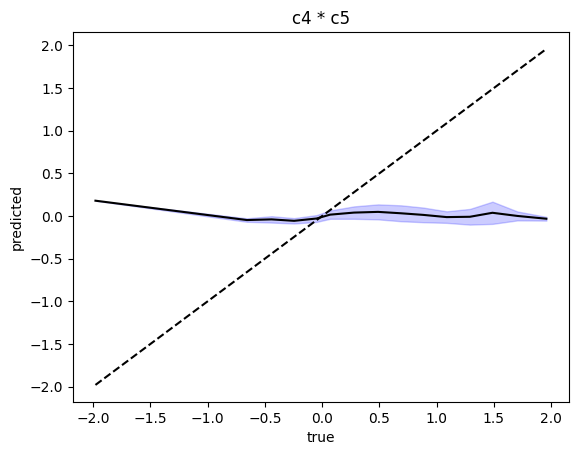

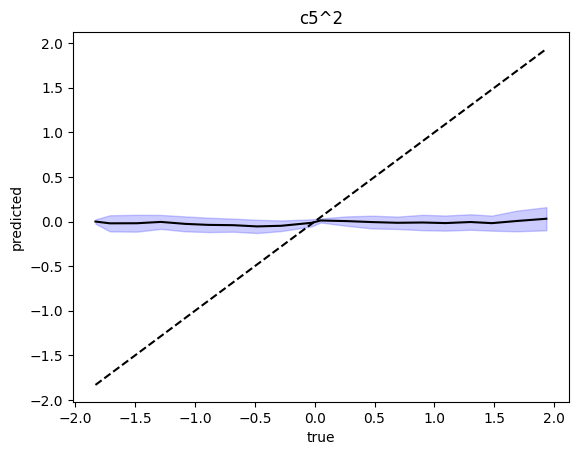

IndexError: index 27 is out of bounds for axis 0 with size 27

In [13]:
num_bins = 20

bins = np.linspace(-2,2,num_bins+1)
print(bins)
for idx, lab in enumerate(label):
    which_bin = (truth_list[idx] > bins[:-1].reshape(-1,1)) & (truth_list[idx] <= bins[1:].reshape(-1,1))
    tmp_truth = []
    tmp_pred = []
    tmp_std = []
    for i in range(num_bins):
        if len(truth_list[idx][which_bin[i]]) == 0:
            pass
        else:
            tmp_truth.append(truth_list[idx][which_bin[i]].mean())
            tmp_pred.append(pred_list[idx][which_bin[i]].mean())
            tmp_std.append(pred_list[idx][which_bin[i]].std())
    tmp_truth = np.array(tmp_truth)
    tmp_pred = np.array(tmp_pred)
    tmp_std = np.array(tmp_std)
    plt.plot(tmp_truth, tmp_pred, color='k')
    plt.fill_between(tmp_truth, tmp_pred+tmp_std,tmp_pred-tmp_std , color='b',alpha=0.2)
    plt.plot([tmp_truth.min(),tmp_truth.max()], [tmp_truth.min(),tmp_truth.max()], 'k--', label='well calib.')
    plt.xlabel('true')
    plt.ylabel('predicted')
    plt.title(label[idx])
    plt.show()

In [14]:
plt.plot(c0_truth, c0_pred-c0_truth, 'x', color='k')
plt.show()
plt.plot(c1_truth, c1_pred-c1_truth, 'x', color='k')
plt.show()
plt.plot(c2_truth, c2_pred-c2_truth, 'x', color='k')
plt.show()
plt.plot(c3_truth, c3_pred-c3_truth, 'x', color='k')
plt.show()
plt.plot(c4_truth, c4_pred-c4_truth, 'x', color='k')
plt.show()
plt.plot(c5_truth, c5_pred-c5_truth, 'x', color='k')
plt.show()

NameError: name 'c0_truth' is not defined